<a href="https://colab.research.google.com/github/Bidhan989/Student-Performance-Prediction-/blob/main/Student_Performance_Prediction_Using_Machine_Learning_for_Grade_Estimation_and_Pass_Fail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing Libraries and Mounting google drive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBRegressor, XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, validation_curve, learning_curve, KFold, cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, classification_report
import shap
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Successfully Imported!")

Successfully Imported!


In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/AI ML/StudentsPerformance.csv'
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


# Exploratory data analysis (EDA)

##Displaying the first 5 columns and rows of dataset


In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##Dataset overview

In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##Checking null values

In [ ]:
# Check Missing Values
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


###The dataset was checked for missing values and none were found.


##Feature Engineering

In [ ]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['pass_fail'] = df['average_score'].apply(lambda x: 'Pass' if x >= 60 else 'Fail')

def categorize_performance(score):
    if score >= 80:
        return 'Excellent'
    elif score >= 70:
        return 'Good'
    elif score >= 60:
        return 'Average'
    else:
        return 'Below Average'

df['performance_category'] = df['average_score'].apply(categorize_performance)

print("New features created successfully!")
df.head()

New features created successfully!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,total_score,pass_fail,performance_category
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,218,Pass,Good
1,female,group C,some college,standard,completed,69,90,88,82.333333,247,Pass,Excellent
2,female,group B,master's degree,standard,none,90,95,93,92.666667,278,Pass,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,148,Fail,Below Average
4,male,group C,some college,standard,none,76,78,75,76.333333,229,Pass,Good


## Basic Statistics


In [ ]:
subjects = ['math score', 'reading score', 'writing score', 'average_score']
stats_df = pd.DataFrame({
    'Subject': ['Math', 'Reading', 'Writing', 'Average'],
    'Mean': [df['math score'].mean(), df['reading score'].mean(),
             df['writing score'].mean(), df['average_score'].mean()],
    'Median': [df['math score'].median(), df['reading score'].median(),
               df['writing score'].median(), df['average_score'].median()],
    'Min': [df['math score'].min(), df['reading score'].min(),
            df['writing score'].min(), df['average_score'].min()],
    'Max': [df['math score'].max(), df['reading score'].max(),
            df['writing score'].max(), df['average_score'].max()],
    'Std': [df['math score'].std(), df['reading score'].std(),
            df['writing score'].std(), df['average_score'].std()]
})

stats_df.round(2)

,Subject,Mean,Median,Min,Max,Std
0,Math,66.09,66.00,0.0,100.0,15.16
1,Reading,69.17,70.00,17.0,100.0,14.60
2,Writing,68.05,69.00,10.0,100.0,15.20
3,Average,67.77,68.33,9.0,100.0,14.26


### Pass/Fail Distribution


In [ ]:
pass_fail_counts = df['pass_fail'].value_counts()
print(pass_fail_counts)
print(f"\nPass Rate: {(pass_fail_counts['Pass'] / len(df) * 100):.2f}%")
print(f"Fail Rate: {(pass_fail_counts['Fail'] / len(df) * 100):.2f}%")

pass_fail
Pass    715
Fail    285
Name: count, dtype: int64

Pass Rate: 71.50%
Fail Rate: 28.50%


## Categorical Features Distribution


In [ ]:
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education',
                    'lunch', 'test preparation course']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
female    518
male      482
Name: count, dtype: int64

race/ethnicity:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental level of education:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test preparation course:
test preparation course
none         642
completed    358
Name: count, dtype: int64


## Score Distribution Visualizations


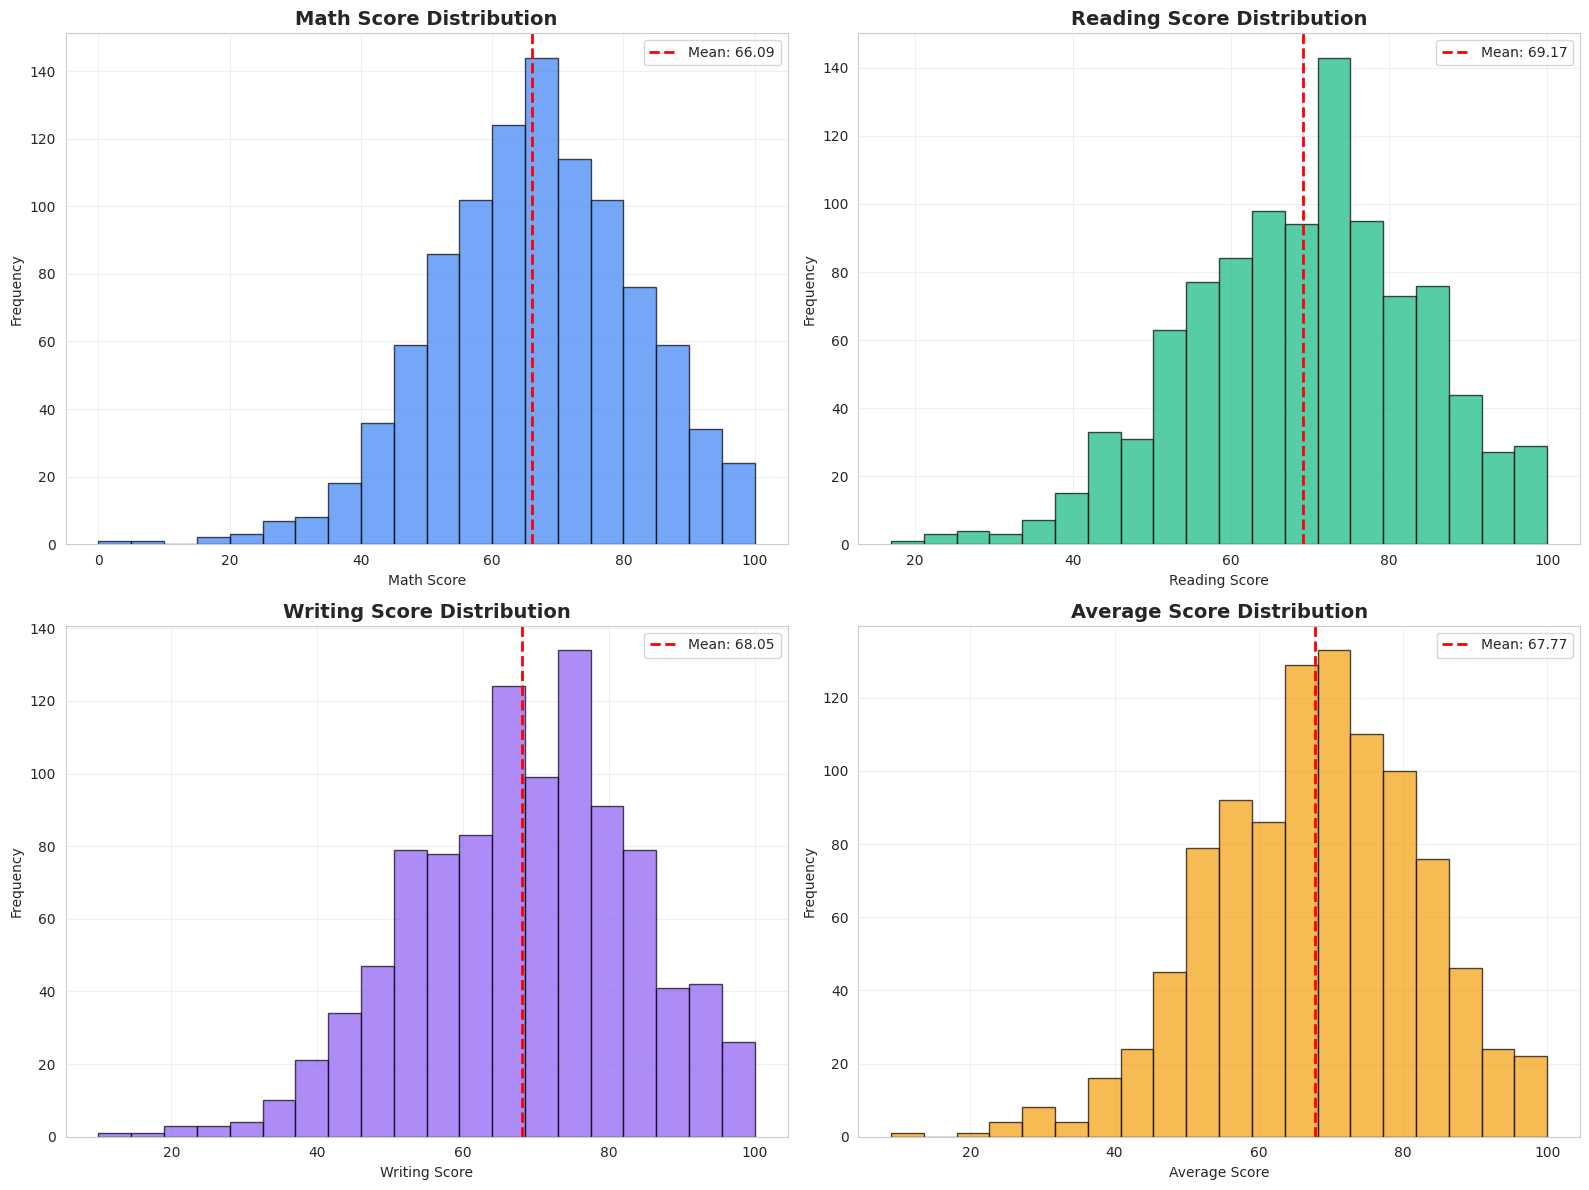

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df['math score'], bins=20, color='#3b82f6', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['math score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["math score"].mean():.2f}')
axes[0, 0].set_title('Math Score Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Math Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df['reading score'], bins=20, color='#10b981', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(df['reading score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["reading score"].mean():.2f}')
axes[0, 1].set_title('Reading Score Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Reading Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(df['writing score'], bins=20, color='#8b5cf6', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df['writing score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["writing score"].mean():.2f}')
axes[1, 0].set_title('Writing Score Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Writing Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df['average_score'], bins=20, color='#f59e0b', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(df['average_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["average_score"].mean():.2f}')
axes[1, 1].set_title('Average Score Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Pass/Fail Visualization


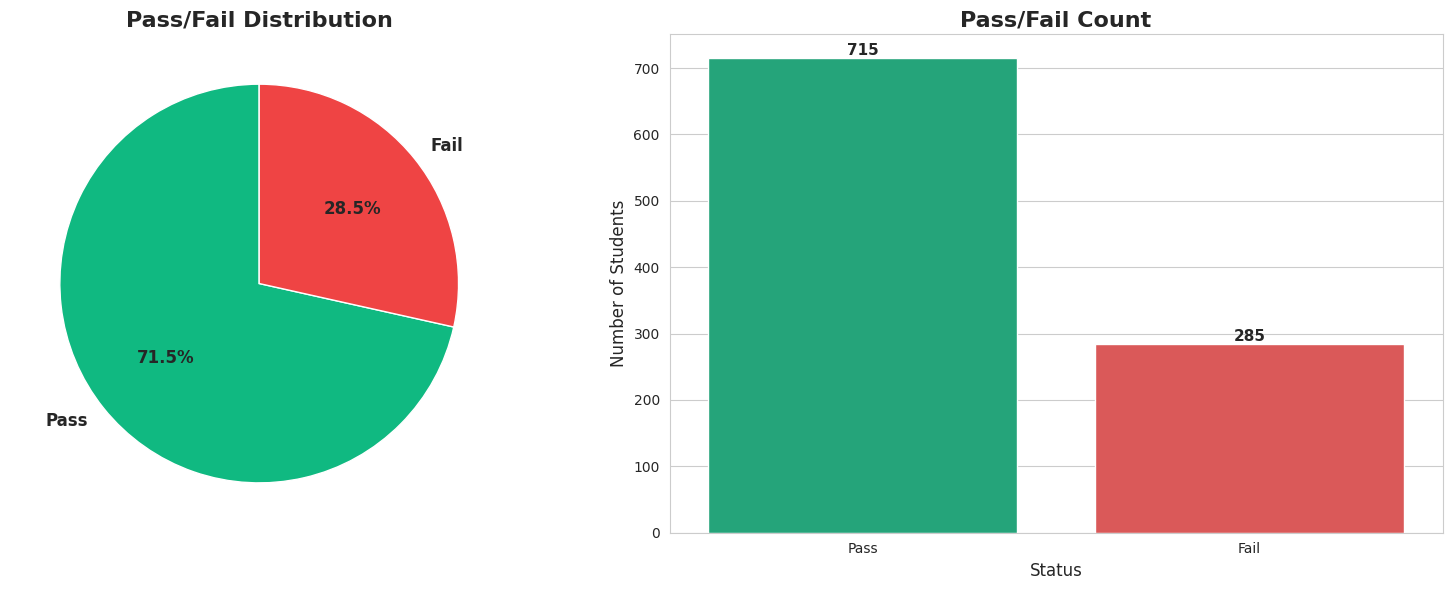

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pass_fail_counts = df['pass_fail'].value_counts()
colors = ['#10b981', '#ef4444']
axes[0].pie(pass_fail_counts, labels=pass_fail_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Pass/Fail Distribution', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='pass_fail', palette={'Pass': '#10b981', 'Fail': '#ef4444'}, ax=axes[1])
axes[1].set_title('Pass/Fail Count', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Status', fontsize=12)
axes[1].set_ylabel('Number of Students', fontsize=12)

for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Gender-wise Performance


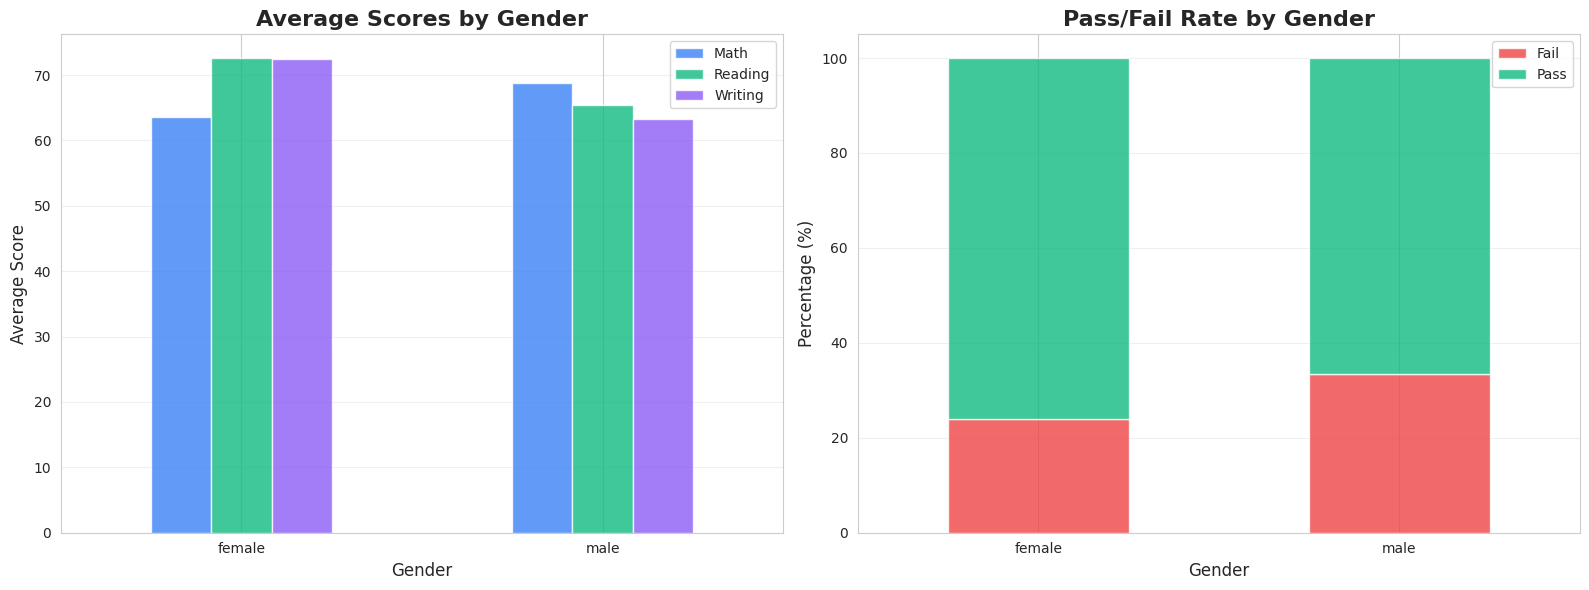

math score               reading score               writing score  \
             mean median    std          mean median    std          mean   
gender                                                                      
female      63.63   65.0  15.49         72.61   73.0  14.38         72.47   
male        68.73   69.0  14.36         65.47   66.0  13.93         63.31   

                     average_score                
       median    std          mean median    std  
gender                                            
female   74.0  14.84         69.57  70.33  14.54  
male     64.0  14.11         65.84  66.33  13.70

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

gender_scores.plot(kind='bar', ax=axes[0], color=['#3b82f6', '#10b981', '#8b5cf6'], alpha=0.8)
axes[0].set_title('Average Scores by Gender', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Average Score', fontsize=12)
axes[0].legend(['Math', 'Reading', 'Writing'], fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

pass_rate_gender = df.groupby(['gender', 'pass_fail']).size().unstack()
pass_rate_gender_pct = pass_rate_gender.div(pass_rate_gender.sum(axis=1), axis=0) * 100

pass_rate_gender_pct.plot(kind='bar', stacked=True, ax=axes[1],
                          color=['#ef4444', '#10b981'], alpha=0.8)
axes[1].set_title('Pass/Fail Rate by Gender', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(['Fail', 'Pass'], fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

df.groupby('gender')[['math score', 'reading score', 'writing score', 'average_score']].agg(['mean', 'median', 'std']).round(2)

### Test Preparation Impact


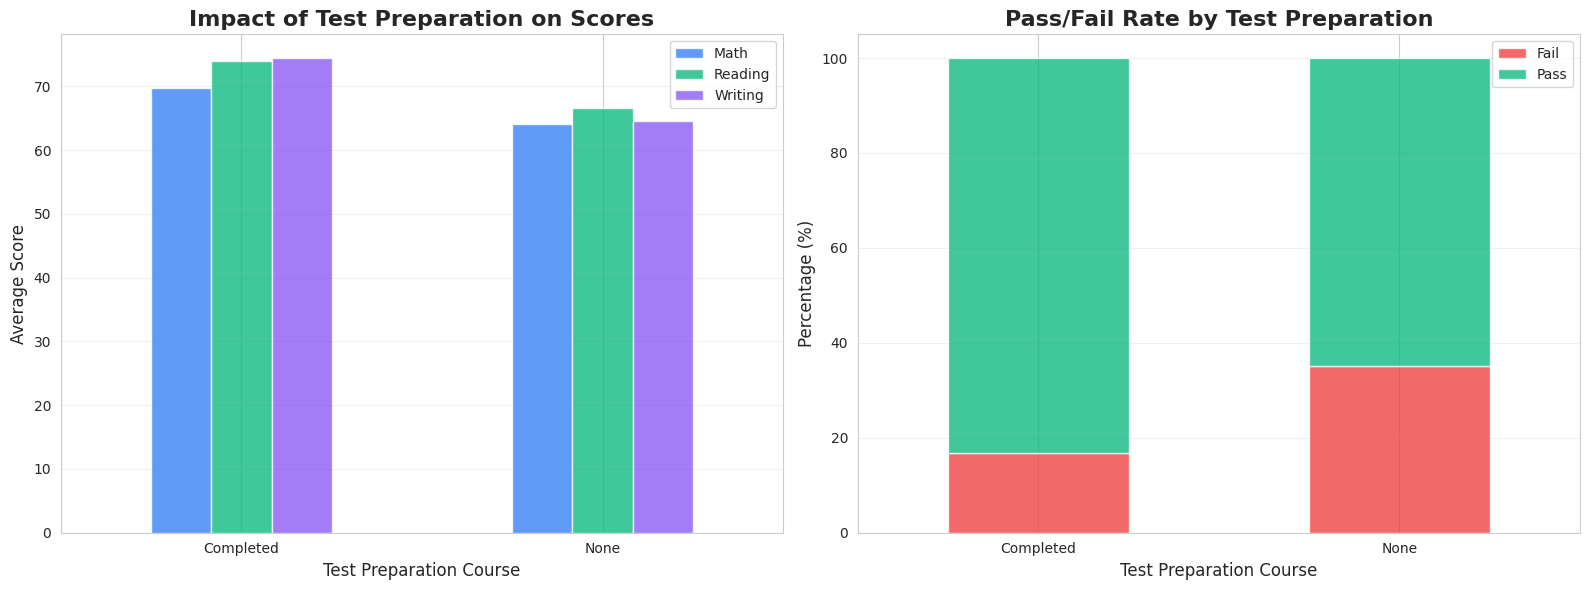

math score       reading score       writing score  \
                              mean count          mean count          mean   
test preparation course                                                      
completed                    69.70   358         73.89   358         74.42   
none                         64.08   642         66.53   642         64.50   

                              average_score        
                        count          mean count  
test preparation course                            
completed                 358         72.67   358  
none                      642         65.04   642

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

test_prep_scores = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

test_prep_scores.plot(kind='bar', ax=axes[0], color=['#3b82f6', '#10b981', '#8b5cf6'], alpha=0.8)
axes[0].set_title('Impact of Test Preparation on Scores', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Test Preparation Course', fontsize=12)
axes[0].set_ylabel('Average Score', fontsize=12)
axes[0].legend(['Math', 'Reading', 'Writing'], fontsize=10)
axes[0].set_xticklabels(['Completed', 'None'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

pass_rate_prep = df.groupby(['test preparation course', 'pass_fail']).size().unstack()
pass_rate_prep_pct = pass_rate_prep.div(pass_rate_prep.sum(axis=1), axis=0) * 100

pass_rate_prep_pct.plot(kind='bar', stacked=True, ax=axes[1],
                        color=['#ef4444', '#10b981'], alpha=0.8)
axes[1].set_title('Pass/Fail Rate by Test Preparation', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Test Preparation Course', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(['Fail', 'Pass'], fontsize=10)
axes[1].set_xticklabels(['Completed', 'None'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

df.groupby('test preparation course')[['math score', 'reading score', 'writing score', 'average_score']].agg(['mean', 'count']).round(2)

### Lunch Type Impact


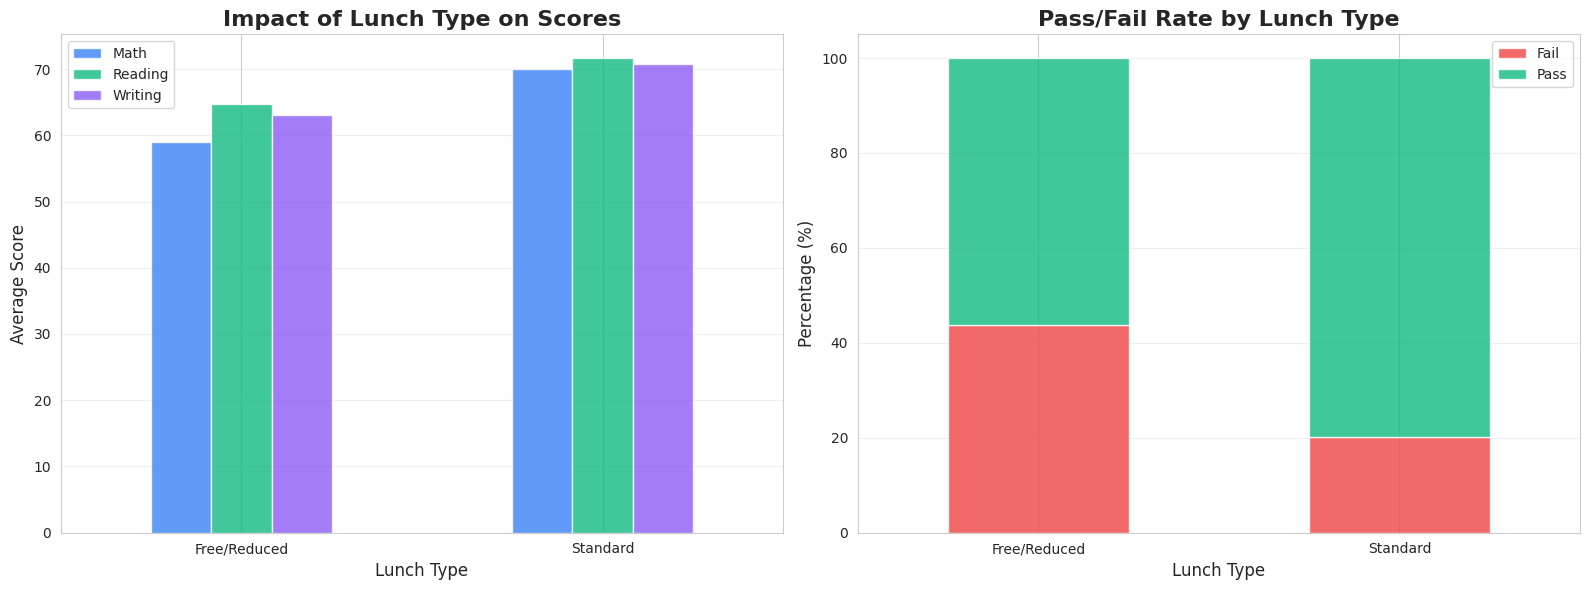

math score       reading score       writing score        \
                   mean count          mean count          mean count   
lunch                                                                   
free/reduced      58.92   355         64.65   355         63.02   355   
standard          70.03   645         71.65   645         70.82   645   

             average_score        
                      mean count  
lunch                             
free/reduced         62.20   355  
standard             70.84   645

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lunch_scores = df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()

lunch_scores.plot(kind='bar', ax=axes[0], color=['#3b82f6', '#10b981', '#8b5cf6'], alpha=0.8)
axes[0].set_title('Impact of Lunch Type on Scores', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Lunch Type', fontsize=12)
axes[0].set_ylabel('Average Score', fontsize=12)
axes[0].legend(['Math', 'Reading', 'Writing'], fontsize=10)
axes[0].set_xticklabels(['Free/Reduced', 'Standard'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

pass_rate_lunch = df.groupby(['lunch', 'pass_fail']).size().unstack()
pass_rate_lunch_pct = pass_rate_lunch.div(pass_rate_lunch.sum(axis=1), axis=0) * 100

pass_rate_lunch_pct.plot(kind='bar', stacked=True, ax=axes[1],
                         color=['#ef4444', '#10b981'], alpha=0.8)
axes[1].set_title('Pass/Fail Rate by Lunch Type', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Lunch Type', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(['Fail', 'Pass'], fontsize=10)
axes[1].set_xticklabels(['Free/Reduced', 'Standard'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

df.groupby('lunch')[['math score', 'reading score', 'writing score', 'average_score']].agg(['mean', 'count']).round(2)

### Parental Education Impact


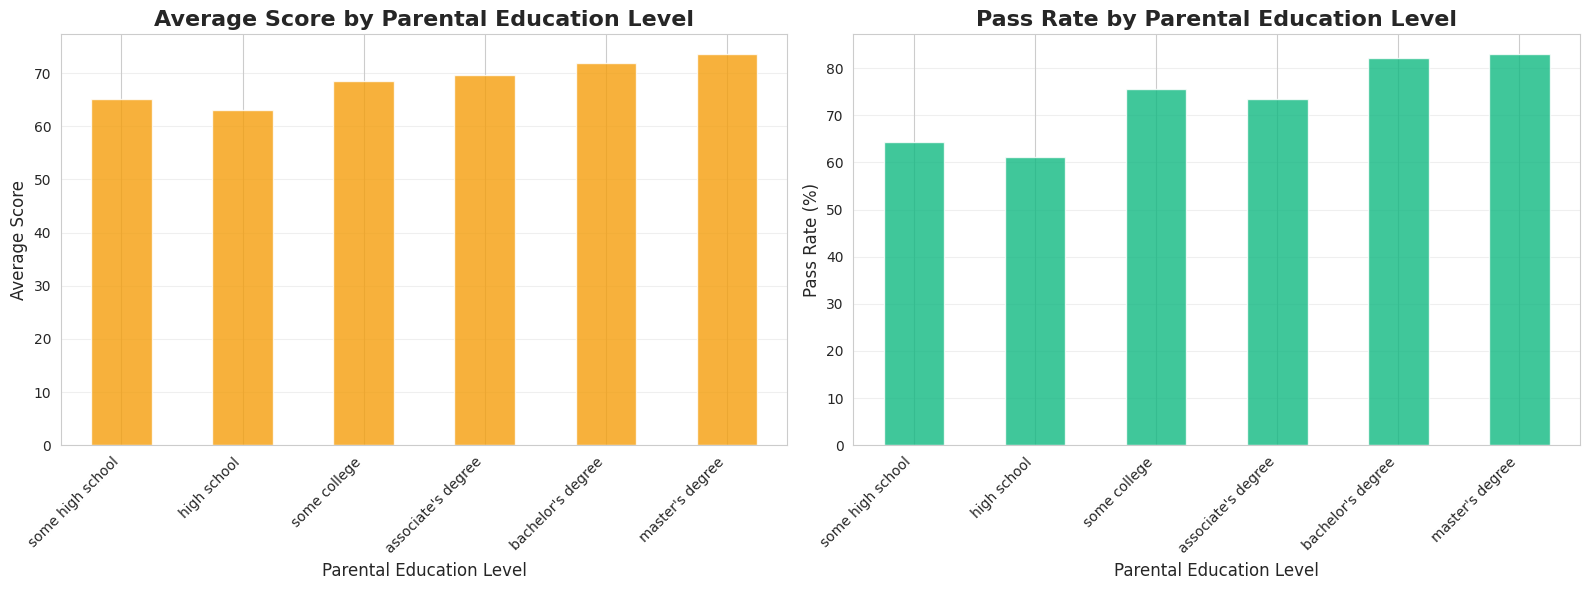

,math score,reading score,writing score,average_score
parental level of education,,,,
associate's degree,67.88,70.93,69.90,69.57
bachelor's degree,69.39,73.00,73.38,71.92
high school,62.14,64.70,62.45,63.10
master's degree,69.75,75.37,75.68,73.60
some college,67.13,69.46,68.84,68.48
some high school,63.50,66.94,64.89,65.11


In [ ]:
education_order = ["some high school", "high school", "some college",
                   "associate's degree", "bachelor's degree", "master's degree"]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
parent_edu_scores = df.groupby('parental level of education')['average_score'].mean().reindex(education_order)
parent_edu_scores.plot(kind='bar', color='#f59e0b', alpha=0.8)
plt.title('Average Score by Parental Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Parental Education Level', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
pass_rate_edu = df.groupby('parental level of education')['pass_fail'].apply(lambda x: (x == 'Pass').mean() * 100).reindex(education_order)
pass_rate_edu.plot(kind='bar', color='#10b981', alpha=0.8)
plt.title('Pass Rate by Parental Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Parental Education Level', fontsize=12)
plt.ylabel('Pass Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

df.groupby('parental level of education')[['math score', 'reading score', 'writing score', 'average_score']].mean().round(2)

### Race/Ethnicity Analysis


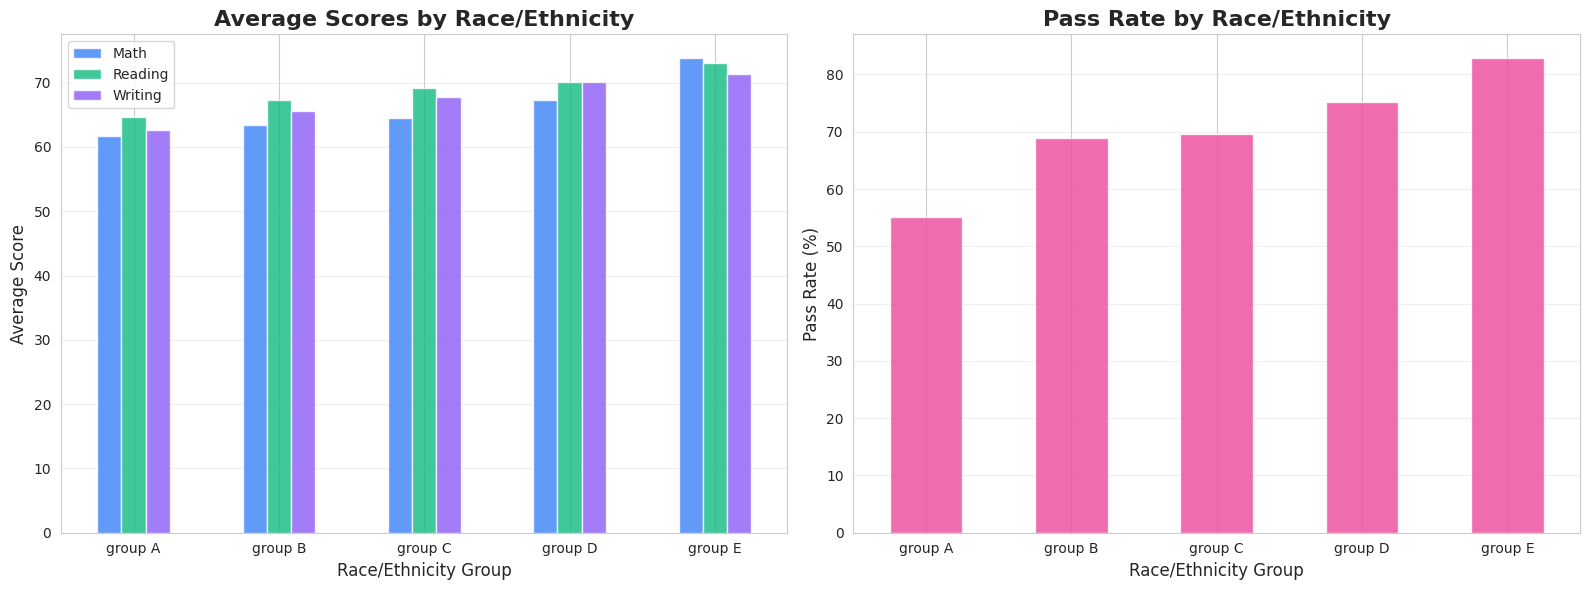

math score       reading score       writing score        \
                     mean count          mean count          mean count   
race/ethnicity                                                            
group A             61.63    89         64.67    89         62.67    89   
group B             63.45   190         67.35   190         65.60   190   
group C             64.46   319         69.10   319         67.83   319   
group D             67.36   262         70.03   262         70.15   262   
group E             73.82   140         73.03   140         71.41   140   

               average_score        
                        mean count  
race/ethnicity                      
group A                62.99    89  
group B                65.47   190  
group C                67.13   319  
group D                69.18   262  
group E                72.75   140

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

race_scores = df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()

race_scores.plot(kind='bar', ax=axes[0], color=['#3b82f6', '#10b981', '#8b5cf6'], alpha=0.8)
axes[0].set_title('Average Scores by Race/Ethnicity', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Race/Ethnicity Group', fontsize=12)
axes[0].set_ylabel('Average Score', fontsize=12)
axes[0].legend(['Math', 'Reading', 'Writing'], fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

pass_rate_race = df.groupby('race/ethnicity')['pass_fail'].apply(lambda x: (x == 'Pass').mean() * 100)
pass_rate_race.plot(kind='bar', ax=axes[1], color='#ec4899', alpha=0.8)
axes[1].set_title('Pass Rate by Race/Ethnicity', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Race/Ethnicity Group', fontsize=12)
axes[1].set_ylabel('Pass Rate (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score', 'average_score']].agg(['mean', 'count']).round(2)

## Correlation Analysis


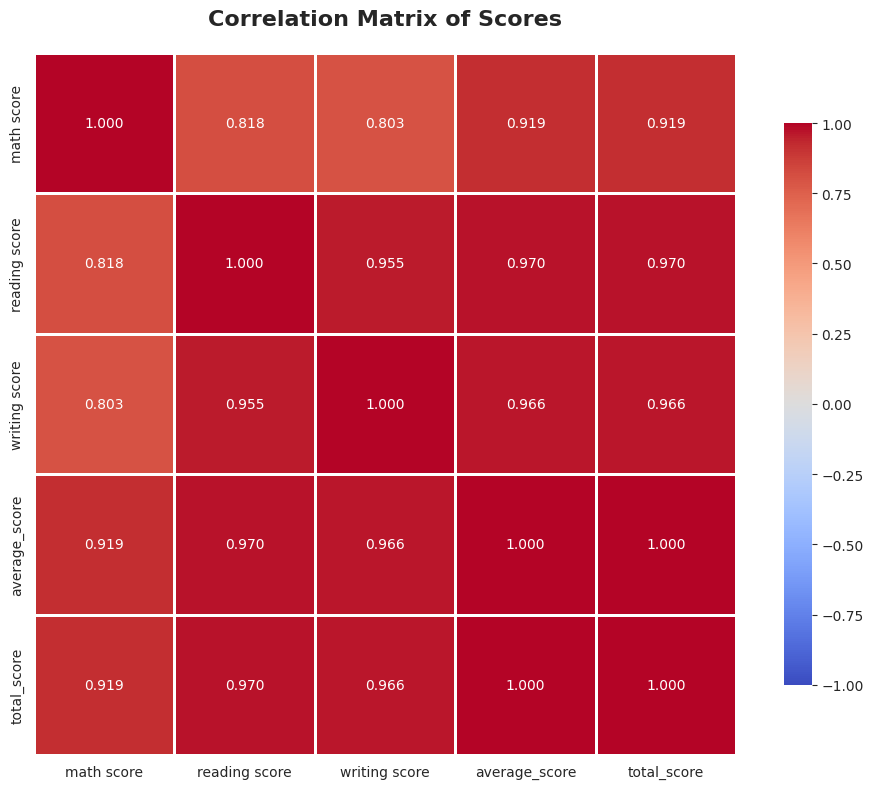

In [ ]:
plt.figure(figsize=(10, 8))

numerical_cols = ['math score', 'reading score', 'writing score', 'average_score', 'total_score']
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)

plt.title('Correlation Matrix of Scores', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Box Plots for Outlier Detection


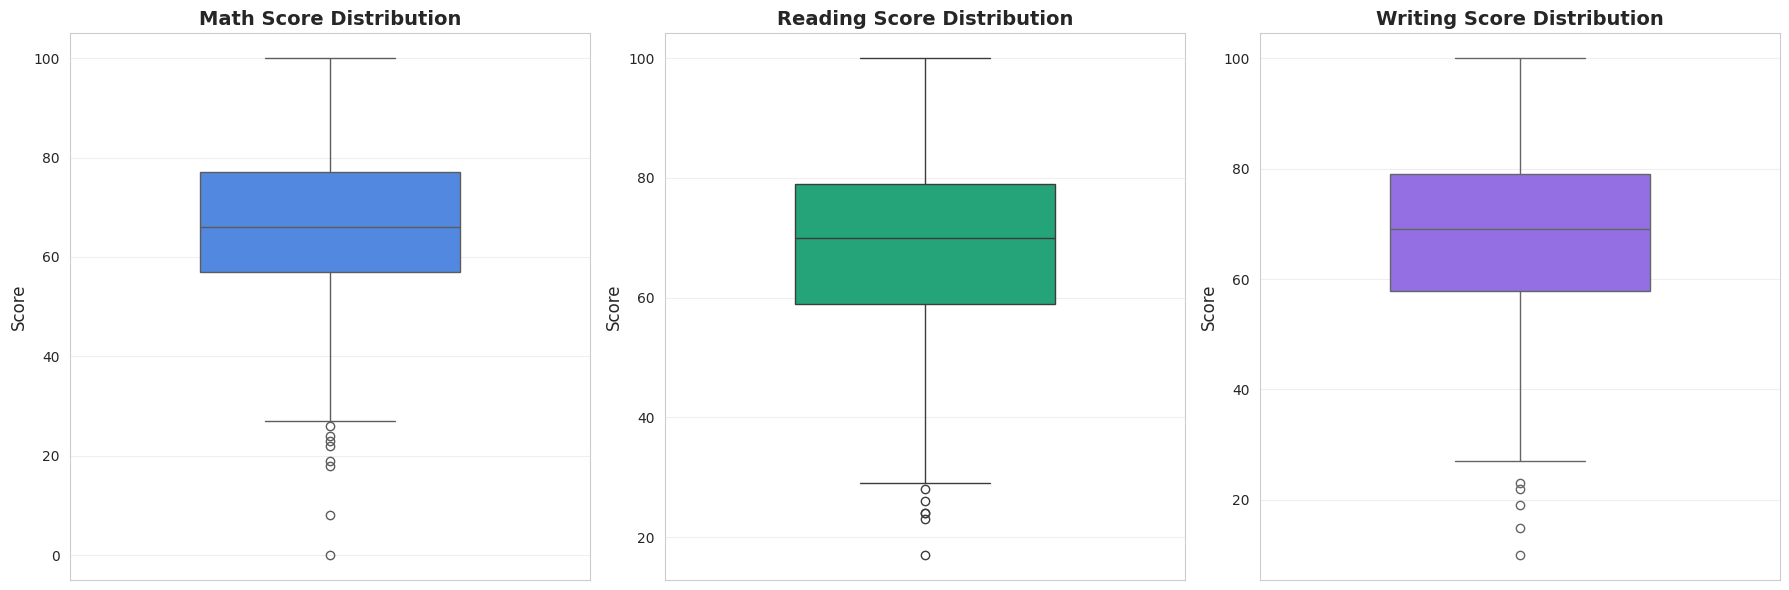

math score: 8 outliers detected
reading score: 6 outliers detected
writing score: 5 outliers detected


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=df['math score'], ax=axes[0], color='#3b82f6', width=0.5)
axes[0].set_title('Math Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

sns.boxplot(y=df['reading score'], ax=axes[1], color='#10b981', width=0.5)
axes[1].set_title('Reading Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

sns.boxplot(y=df['writing score'], ax=axes[2], color='#8b5cf6', width=0.5)
axes[2].set_title('Writing Score Distribution', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for col in ['math score', 'reading score', 'writing score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    print(f"{col}: {len(outliers)} outliers detected")

## Key Insights Summary


In [ ]:
print("KEY INSIGHTS FROM EDA:\n")

print(f"Total Students: {len(df)}")
print(f"Average Math Score: {df['math score'].mean():.2f}")
print(f"Average Reading Score: {df['reading score'].mean():.2f}")
print(f"Average Writing Score: {df['writing score'].mean():.2f}")
print(f"Overall Pass Rate: {(df['pass_fail'] == 'Pass').mean() * 100:.2f}%\n")

completed_avg = df[df['test preparation course'] == 'completed']['average_score'].mean()
none_avg = df[df['test preparation course'] == 'none']['average_score'].mean()
print(f"Test Prep Impact: {completed_avg - none_avg:.2f} points improvement\n")

print("EDA Complete - Ready for modeling!")

KEY INSIGHTS FROM EDA:

Total Students: 1000
Average Math Score: 66.09
Average Reading Score: 69.17
Average Writing Score: 68.05
Overall Pass Rate: 71.50%

Test Prep Impact: 7.63 points improvement

EDA Complete - Ready for modeling!


#Ridge Regression (Math Score Prediction)

##Why Ridge Regression?

Ridge Regression is a regularized linear regression model that prevents overfitting while maintaining interpretability.

##Key Advantages:

* Handles Multicollinearity: Reading and writing scores are highly correlated; Ridge stabilizes coefficients

* Regularization (L2 Penalty): Prevents large coefficients and improves generalization

* Fast & Efficient: Trains quickly even on large datasets

* Interpretable Model: Coefficients clearly show the impact of each feature

* Strong Baseline Regressor: Serves as a benchmark for more complex models

* Low Overfitting Risk: Penalization controls model complexity

Use Case in Project:
Used to predict math scores based on demographic and academic features.

#Support Vector Machine (SVM) Classifier (Pass / Fail Prediction)

##Why SVM?

Support Vector Machine is a powerful margin-based classifier that performs well in high-dimensional feature spaces.

##Key Advantages:

* Maximizes Decision Margin: Improves separation between Pass and Fail classes

* Effective in High Dimensions: Works well with scaled numerical and encoded categorical features

* Robust to Overfitting: Margin maximization improves generalization

* Kernel Capability: Can model non-linear class boundaries

* Probability Estimates: Provides confidence scores for predictions

* Performs Well with Class Imbalance: Combined with class weighting

#Why Class Weighting Was Necessary (SVM & XGBoost Classifier)

##The dataset is imbalanced:

Pass: 715 students (71.5%)

Fail: 285 students (28.5%)

Without class weighting:

Model tends to predict “Pass” excessively

High accuracy but poor recall for “Fail”

At-risk students are misclassified

With class weighting:

Misclassification of Fail class is penalized more

Improves recall, precision, and F1-score for minority class

Produces educationally meaningful predictions

#XGBoost Regressor (Advanced Math Score Prediction)

##Why XGBoost Regression?

XGBoost is a powerful gradient boosting algorithm that builds trees sequentially to minimize prediction errors.

##Key Advantages:

* Captures Non-Linear Relationships: Models complex interactions between features

* High Predictive Accuracy: Consistently outperforms traditional regressors

* Handles Feature Interactions Automatically

* Built-in Regularization: Reduces overfitting

* Robust to Outliers: Tree-based splits reduce sensitivity to extreme values

* Scalable & Efficient: Optimized for performance

Use Case in Project:
Used alongside Ridge Regression to improve math score prediction accuracy.


#XGBoost Classifier (Pass / Fail Prediction)

##Why XGBoost Classification?

XGBoost Classifier is a state-of-the-art ensemble method widely used in real-world ML systems.

##Key Advantages:

* Ensemble Boosting Method: Combines many weak learners into a strong classifier

* Handles Non-Linear Decision Boundaries

* Feature Importance Analysis: Identifies key academic risk factors

* Built-in Class Imbalance Handling: scale_pos_weight directly addresses imbalance

* High Recall for Minority Class: Effectively identifies failing students

* Excellent Generalization: Performs well on unseen data

#Choosing Model and Model Training

In [ ]:
df_model = df.copy()

label_encoders = {}
categorical_columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in categorical_columns:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col])
    label_encoders[col] = le

print("Categorical variables encoded successfully!")
df_model[['gender', 'gender_encoded', 'lunch', 'lunch_encoded']].head()

Categorical variables encoded successfully!


,gender,gender_encoded,lunch,lunch_encoded
0,female,0,standard,1
1,female,0,standard,1
2,female,0,standard,1
3,male,1,free/reduced,0
4,male,1,standard,1


In [ ]:
feature_cols_demographic = ['gender_encoded', 'race/ethnicity_encoded',
                            'parental level of education_encoded', 'lunch_encoded',
                            'test preparation course_encoded']

# REGRESSION: Predict math score from reading + writing + demographics
X_regression = df_model[feature_cols_demographic + ['reading score', 'writing score']]
y_regression = df_model['math score']

# CLASSIFICATION: Predict pass/fail from reading + writing + demographics (NO math!)
X_classification = df_model[feature_cols_demographic + ['reading score', 'writing score']]
y_classification = df_model['pass_fail'].apply(lambda x: 1 if x == 'Pass' else 0)

print("=" * 70)
print("FEATURE ENGINEERING - REALISTIC EARLY PREDICTION SCENARIO")
print("=" * 70)

print(f"\nREGRESSION TASK (Predict Math Score):")
print(f"  Features: {list(X_regression.columns)}")
print(f"  Shape: {X_regression.shape}")
print(f"  Target: Math score (continuous)")

print(f"\nCLASSIFICATION TASK (Predict Pass/Fail):")
print(f"  Features: {list(X_classification.columns)}")
print(f"  Shape: {X_classification.shape}")
print(f"  Target: Pass/Fail (binary)")

print(f"\n NO DATA LEAKAGE: Math score excluded from classification")

print(f"\nClass distribution:")
print(f"  Pass (1): {(y_classification == 1).sum()} ({(y_classification == 1).sum()/len(y_classification)*100:.1f}%)")
print(f"  Fail (0): {(y_classification == 0).sum()} ({(y_classification == 0).sum()/len(y_classification)*100:.1f}%)")

FEATURE ENGINEERING - REALISTIC EARLY PREDICTION SCENARIO

REGRESSION TASK (Predict Math Score):
  Features: ['gender_encoded', 'race/ethnicity_encoded', 'parental level of education_encoded', 'lunch_encoded', 'test preparation course_encoded', 'reading score', 'writing score']
  Shape: (1000, 7)
  Target: Math score (continuous)

CLASSIFICATION TASK (Predict Pass/Fail):
  Features: ['gender_encoded', 'race/ethnicity_encoded', 'parental level of education_encoded', 'lunch_encoded', 'test preparation course_encoded', 'reading score', 'writing score']
  Shape: (1000, 7)
  Target: Pass/Fail (binary)

 NO DATA LEAKAGE: Math score excluded from classification

Class distribution:
  Pass (1): 715 (71.5%)
  Fail (0): 285 (28.5%)


In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42
)

print("Train-Test Split Complete!")
print(f"\nRegression - Train: {X_train_reg.shape[0]}, Test: {X_test_reg.shape[0]}")
print(f"Classification - Train: {X_train_clf.shape[0]}, Test: {X_test_clf.shape[0]}")
print(f"\nClassification Test Set Distribution:")
print(f"Pass: {(y_test_clf == 1).sum()}, Fail: {(y_test_clf == 0).sum()}")

Train-Test Split Complete!

Regression - Train: 800, Test: 200
Classification - Train: 800, Test: 200

Classification Test Set Distribution:
Pass: 138, Fail: 62


## Feature Scaling (Required for SVM, beneficial for Ridge)


In [ ]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print(" Feature scaling completed!")
print(f"Scaled training set shape (regression): {X_train_reg_scaled.shape}")
print(f"Scaled training set shape (classification): {X_train_clf_scaled.shape}")# Feature Scaling (Required for SVM, beneficial for Ridge)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Feature scaling completed!")
print(f"Scaled training set shape (regression): {X_train_reg_scaled.shape}")
print(f"Scaled training set shape (classification): {X_train_clf_scaled.shape}")

 Feature scaling completed!
Scaled training set shape (regression): (800, 7)
Scaled training set shape (classification): (800, 7)
Feature scaling completed!
Scaled training set shape (regression): (800, 7)
Scaled training set shape (classification): (800, 7)


##REGRESSION MODELS (Grade Prediction)

###RIDGE REGRESSION

In [ ]:
print("=" * 60)
print("RIDGE REGRESSION - GRADE PREDICTION")
print("=" * 60)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_ridge = ridge_model.predict(X_test_reg_scaled)

ridge_mae = mean_absolute_error(y_test_reg, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))
ridge_r2 = r2_score(y_test_reg, y_pred_ridge)

print(f"\nMean Absolute Error (MAE): {ridge_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {ridge_rmse:.4f}")
print(f"R² Score: {ridge_r2:.4f}")
print(f"\nInterpretation: Model explains {ridge_r2*100:.2f}% of variance in scores")

RIDGE REGRESSION - GRADE PREDICTION

Mean Absolute Error (MAE): 4.1302
Root Mean Squared Error (RMSE): 5.3173
R² Score: 0.8838

Interpretation: Model explains 88.38% of variance in scores


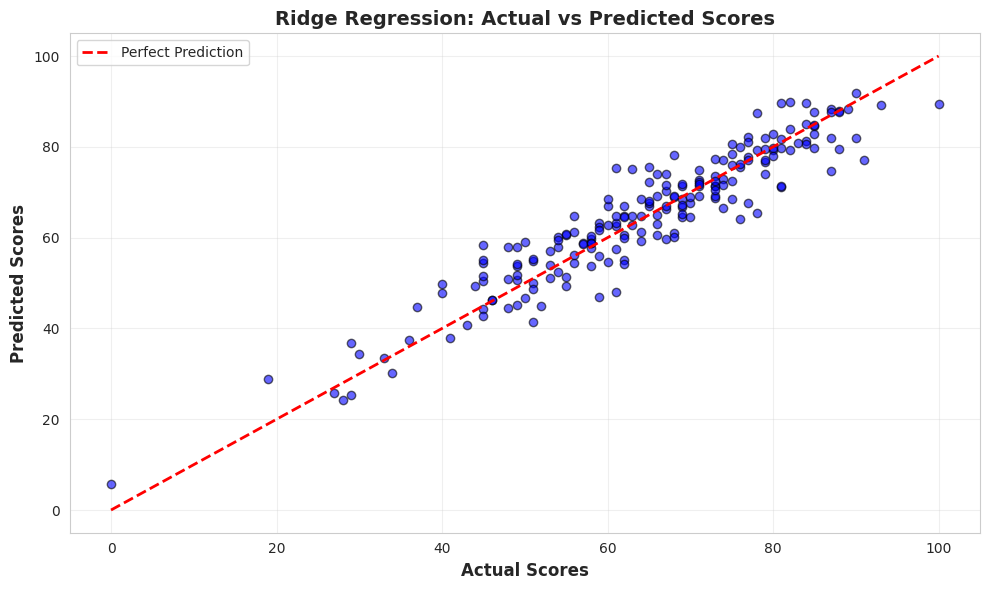

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_ridge, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Scores', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Scores', fontsize=12, fontweight='bold')
plt.title('Ridge Regression: Actual vs Predicted Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###XGBOOST REGRESSOR

In [ ]:
print("=" * 60)
print("XGBOOST REGRESSOR - GRADE PREDICTION")
print("=" * 60)

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train_reg, y_train_reg)

y_pred_xgb_reg = xgb_reg.predict(X_test_reg)

xgb_mae = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
xgb_r2 = r2_score(y_test_reg, y_pred_xgb_reg)

print(f"\nMean Absolute Error (MAE): {xgb_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.4f}")
print(f"R² Score: {xgb_r2:.4f}")
print(f"\nInterpretation: Model explains {xgb_r2*100:.2f}% of variance in scores")

XGBOOST REGRESSOR - GRADE PREDICTION

Mean Absolute Error (MAE): 4.6598
Root Mean Squared Error (RMSE): 5.9604
R² Score: 0.8540

Interpretation: Model explains 85.40% of variance in scores


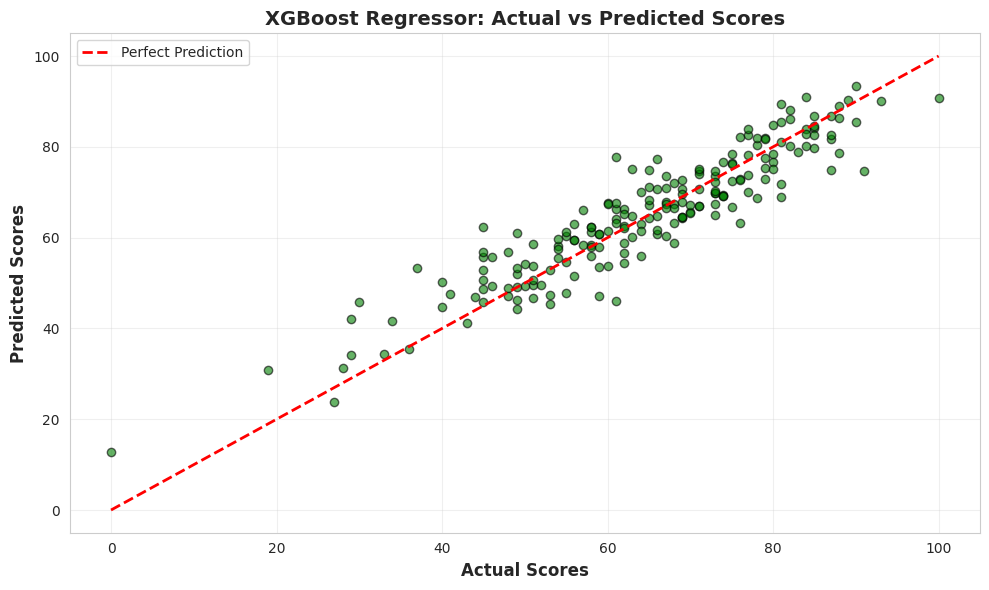

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_xgb_reg, alpha=0.6, color='green', edgecolors='k')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Scores', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Scores', fontsize=12, fontweight='bold')
plt.title('XGBoost Regressor: Actual vs Predicted Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###Result of the models


REGRESSION MODELS COMPARISON
            Model      MAE     RMSE  R² Score
 Ridge Regression 4.130188 5.317331  0.883808
XGBoost Regressor 4.659807 5.960422  0.854003


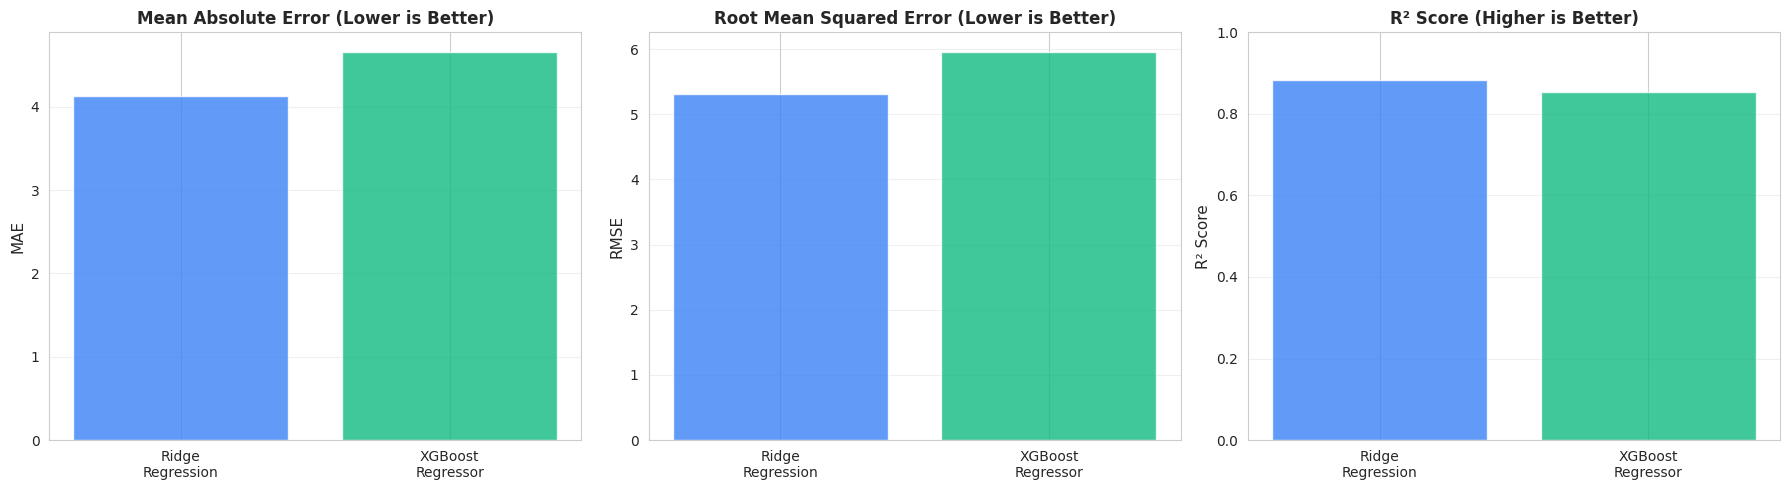


 Best Model for Grade Prediction: Ridge Regression
 Performance Difference: 2.98% in R² Score


In [ ]:
regression_results = pd.DataFrame({
    'Model': ['Ridge Regression', 'XGBoost Regressor'],
    'MAE': [ridge_mae, xgb_mae],
    'RMSE': [ridge_rmse, xgb_rmse],
    'R² Score': [ridge_r2, xgb_r2]
})

print("\n" + "=" * 60)
print("REGRESSION MODELS COMPARISON")
print("=" * 60)
print(regression_results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Ridge\nRegression', 'XGBoost\nRegressor']
mae_scores = [ridge_mae, xgb_mae]
rmse_scores = [ridge_rmse, xgb_rmse]
r2_scores = [ridge_r2, xgb_r2]

axes[0].bar(models, mae_scores, color=['#3b82f6', '#10b981'], alpha=0.8)
axes[0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models, rmse_scores, color=['#3b82f6', '#10b981'], alpha=0.8)
axes[1].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models, r2_scores, color=['#3b82f6', '#10b981'], alpha=0.8)
axes[2].set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Best Model for Grade Prediction: {'XGBoost Regressor' if xgb_r2 > ridge_r2 else 'Ridge Regression'}")
print(f" Performance Difference: {abs(xgb_r2 - ridge_r2)*100:.2f}% in R² Score")

##Classificaion Models (Pass/fail)

###Support Vector Machine (SVM)

In [ ]:
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_clf.fit(X_train_clf_scaled, y_train_clf)

y_pred_svm = svm_clf.predict(X_test_clf_scaled)
y_pred_svm_proba = svm_clf.predict_proba(X_test_clf_scaled)

svm_accuracy = accuracy_score(y_test_clf, y_pred_svm)
svm_precision = precision_score(y_test_clf, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test_clf, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test_clf, y_pred_svm, average='weighted')

print(f"\nAccuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"Precision (weighted): {svm_precision:.4f}")
print(f"Recall (weighted): {svm_recall:.4f}")
print(f"F1-Score (weighted): {svm_f1:.4f}")

print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
print(classification_report(y_test_clf, y_pred_svm, target_names=['Fail', 'Pass']))


Accuracy: 0.9350 (93.50%)
Precision (weighted): 0.9393
Recall (weighted): 0.9350
F1-Score (weighted): 0.9359

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

        Fail       0.86      0.95      0.90        62
        Pass       0.98      0.93      0.95       138

    accuracy                           0.94       200
   macro avg       0.92      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200



###SVM confusion matrix

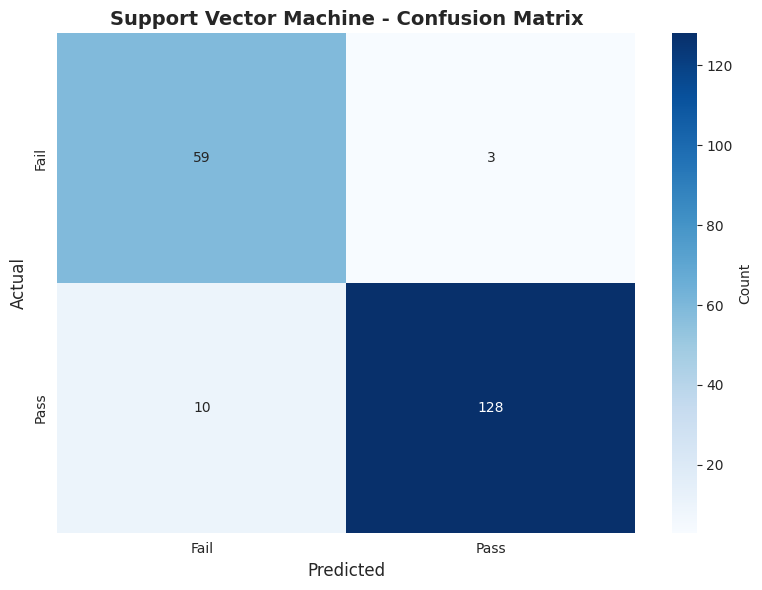

True Negatives (Correctly predicted Fail): 59
False Positives (Predicted Pass, Actually Fail): 3
False Negatives (Predicted Fail, Actually Pass): 10
True Positives (Correctly predicted Pass): 128


In [ ]:
cm_svm = confusion_matrix(y_test_clf, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'],
            cbar_kws={'label': 'Count'})
plt.title('Support Vector Machine - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_svm.ravel()
print(f"True Negatives (Correctly predicted Fail): {tn}")
print(f"False Positives (Predicted Pass, Actually Fail): {fp}")
print(f"False Negatives (Predicted Fail, Actually Pass): {fn}")
print(f"True Positives (Correctly predicted Pass): {tp}")

###XGBOOST Classifier

In [ ]:
print("=" * 60)
print("XGBOOST CLASSIFIER - PASS/FAIL PREDICTION")
print("=" * 60)

xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=2.51,  # 715/285 = 2.51 for class balance
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train_clf, y_train_clf)

y_pred_xgb = xgb_clf.predict(X_test_clf)
y_pred_xgb_proba = xgb_clf.predict_proba(X_test_clf)

xgb_accuracy = accuracy_score(y_test_clf, y_pred_xgb)
xgb_precision = precision_score(y_test_clf, y_pred_xgb, average='weighted')
xgb_recall = recall_score(y_test_clf, y_pred_xgb, average='weighted')
xgb_f1 = f1_score(y_test_clf, y_pred_xgb, average='weighted')

print(f"\nAccuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print(f"Precision (weighted): {xgb_precision:.4f}")
print(f"Recall (weighted): {xgb_recall:.4f}")
print(f"F1-Score (weighted): {xgb_f1:.4f}")

print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
print(classification_report(y_test_clf, y_pred_xgb, target_names=['Fail', 'Pass']))

XGBOOST CLASSIFIER - PASS/FAIL PREDICTION

Accuracy: 0.9650 (96.50%)
Precision (weighted): 0.9650
Recall (weighted): 0.9650
F1-Score (weighted): 0.9648

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

        Fail       0.97      0.92      0.94        62
        Pass       0.96      0.99      0.97       138

    accuracy                           0.96       200
   macro avg       0.97      0.95      0.96       200
weighted avg       0.97      0.96      0.96       200



###XGBOOST Classifier Confusion Matrix

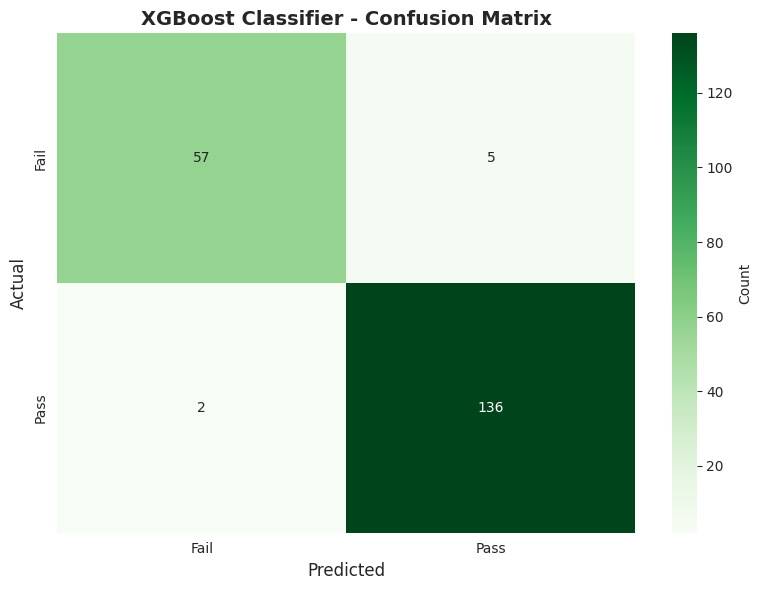

True Negatives (Correctly predicted Fail): 57
False Positives (Predicted Pass, Actually Fail): 5
False Negatives (Predicted Fail, Actually Pass): 2
True Positives (Correctly predicted Pass): 136


In [ ]:
cm_xgb = confusion_matrix(y_test_clf, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'],
            cbar_kws={'label': 'Count'})
plt.title('XGBoost Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"True Negatives (Correctly predicted Fail): {tn}")
print(f"False Positives (Predicted Pass, Actually Fail): {fp}")
print(f"False Negatives (Predicted Fail, Actually Pass): {fn}")
print(f"True Positives (Correctly predicted Pass): {tp}")

###Side by side comparision

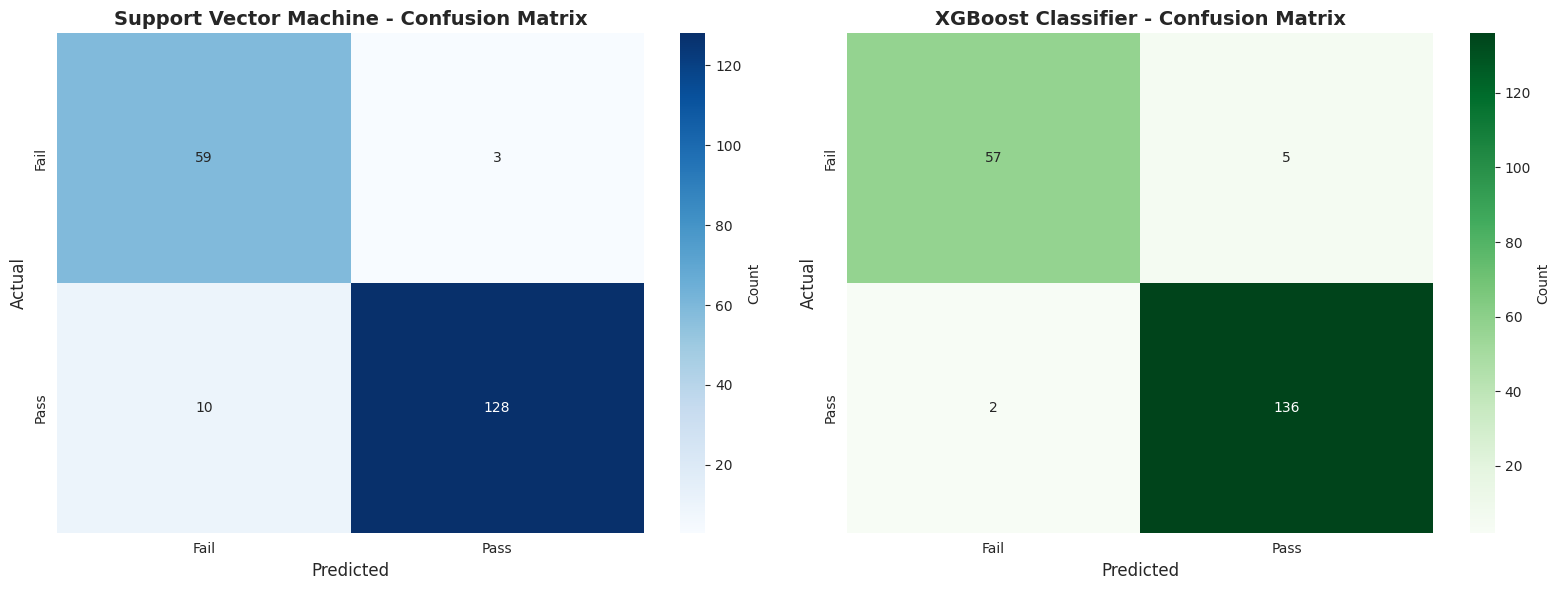

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Support Vector Machine - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('XGBoost Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

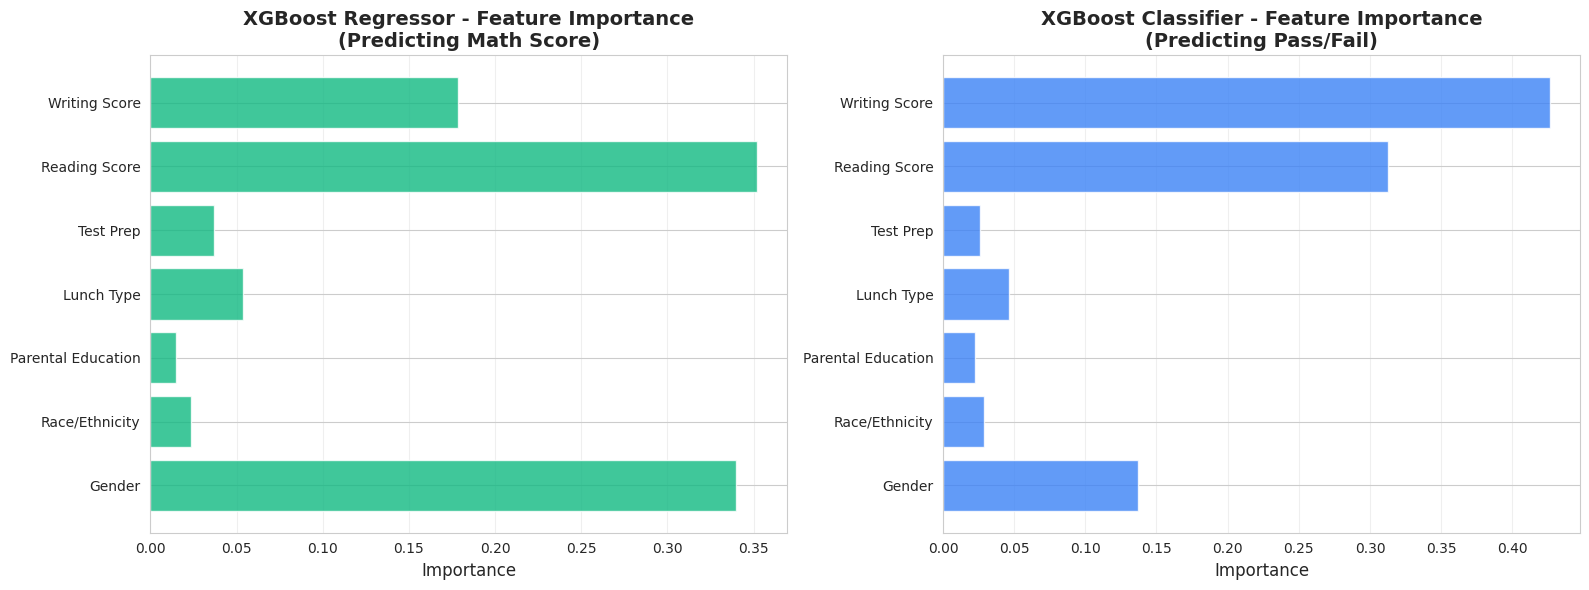


REGRESSION - Feature Importance Rankings (Predicting Math Score):
           Feature  Importance
     Reading Score    0.352111
            Gender    0.339818
     Writing Score    0.178531
        Lunch Type    0.053731
         Test Prep    0.037025
    Race/Ethnicity    0.023691
Parental Education    0.015092


CLASSIFICATION - Feature Importance Rankings (Predicting Pass/Fail):
           Feature  Importance
     Writing Score    0.426205
     Reading Score    0.312799
            Gender    0.137297
        Lunch Type    0.046191
    Race/Ethnicity    0.029053
         Test Prep    0.025668
Parental Education    0.022786


In [ ]:
feature_names_reg = ['Gender', 'Race/Ethnicity', 'Parental Education', 'Lunch Type', 'Test Prep', 'Reading Score', 'Writing Score']
feature_names_clf = ['Gender', 'Race/Ethnicity', 'Parental Education', 'Lunch Type', 'Test Prep', 'Reading Score', 'Writing Score']

importance_reg = xgb_reg.feature_importances_
importance_clf = xgb_clf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(feature_names_reg, importance_reg, color='#10b981', alpha=0.8)
axes[0].set_title('XGBoost Regressor - Feature Importance\n(Predicting Math Score)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(feature_names_clf, importance_clf, color='#3b82f6', alpha=0.8)
axes[1].set_title('XGBoost Classifier - Feature Importance\n(Predicting Pass/Fail)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

importance_reg_df = pd.DataFrame({
    'Feature': feature_names_reg,
    'Importance': importance_reg
}).sort_values('Importance', ascending=False)

importance_clf_df = pd.DataFrame({
    'Feature': feature_names_clf,
    'Importance': importance_clf
}).sort_values('Importance', ascending=False)

print("\nREGRESSION - Feature Importance Rankings (Predicting Math Score):")
print(importance_reg_df.to_string(index=False))

print("\n" + "="*60)
print("\nCLASSIFICATION - Feature Importance Rankings (Predicting Pass/Fail):")
print(importance_clf_df.to_string(index=False))

##Per-Class Performance Comparison

Class                  Model  Precision   Recall  F1-Score
 Fail Support Vector Machine   0.855072 0.951613  0.900763
 Pass Support Vector Machine   0.977099 0.927536  0.951673
 Fail                XGBoost   0.966102 0.919355  0.942149
 Pass                XGBoost   0.964539 0.985507  0.974910


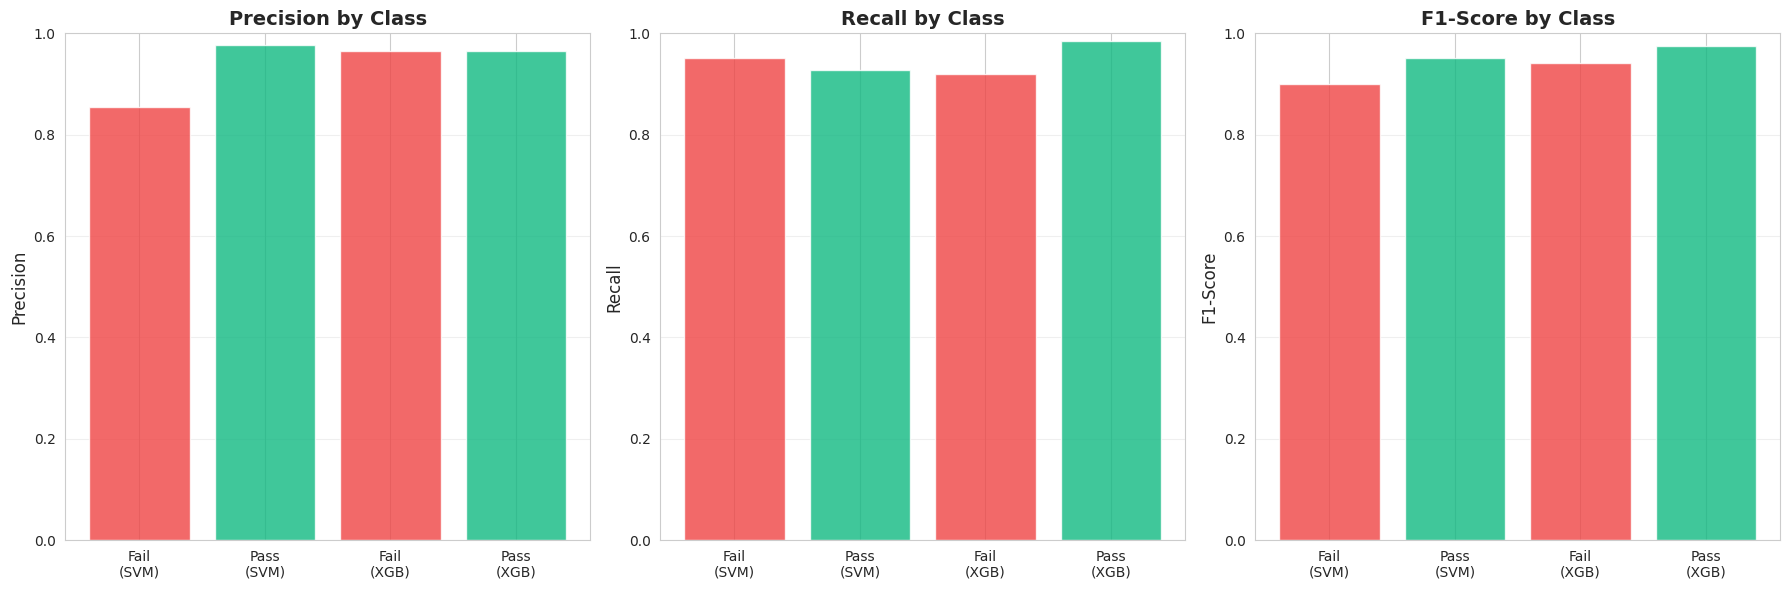


 Key Insight:
Fail Class Detection (Recall) - SVM: 95.16%
Fail Class Detection (Recall) - XGBoost: 91.94%

 Improvement with XGBoost: -3.23%


In [ ]:
svm_metrics = precision_recall_fscore_support(y_test_clf, y_pred_svm, average=None, labels=[0, 1])
xgb_metrics = precision_recall_fscore_support(y_test_clf, y_pred_xgb, average=None, labels=[0, 1])

per_class_comparison = pd.DataFrame({
    'Class': ['Fail', 'Pass', 'Fail', 'Pass'],
    'Model': ['Support Vector Machine', 'Support Vector Machine', 'XGBoost', 'XGBoost'],
    'Precision': [svm_metrics[0][0], svm_metrics[0][1], xgb_metrics[0][0], xgb_metrics[0][1]],
    'Recall': [svm_metrics[1][0], svm_metrics[1][1], xgb_metrics[1][0], xgb_metrics[1][1]],
    'F1-Score': [svm_metrics[2][0], svm_metrics[2][1], xgb_metrics[2][0], xgb_metrics[2][1]]
})

print(per_class_comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

class_labels = ['Fail\n(SVM)', 'Pass\n(SVM)', 'Fail\n(XGB)', 'Pass\n(XGB)']
colors = ['#ef4444', '#10b981', '#ef4444', '#10b981']

axes[0].bar(class_labels, per_class_comparison['Precision'], color=colors, alpha=0.8)
axes[0].set_title('Precision by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(class_labels, per_class_comparison['Recall'], color=colors, alpha=0.8)
axes[1].set_title('Recall by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(class_labels, per_class_comparison['F1-Score'], color=colors, alpha=0.8)
axes[2].set_title('F1-Score by Class', fontsize=14, fontweight='bold')
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Key Insight:")
print(f"Fail Class Detection (Recall) - SVM: {svm_metrics[1][0]:.2%}")
print(f"Fail Class Detection (Recall) - XGBoost: {xgb_metrics[1][0]:.2%}")
print(f"\n Improvement with XGBoost: {(xgb_metrics[1][0] - svm_metrics[1][0])*100:.2f}%")

##Learning Curve for the Models

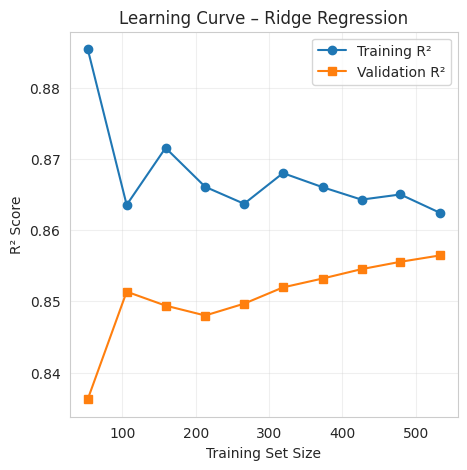

Ridge Regression:
Final Training R²: 0.8624
Final Validation R²: 0.8564
Gap: 0.0060


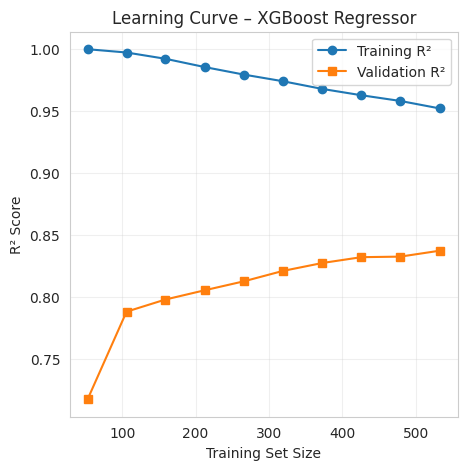

XGBoost Regressor:
Final Training R²: 0.9519
Final Validation R²: 0.8371
Gap: 0.1148


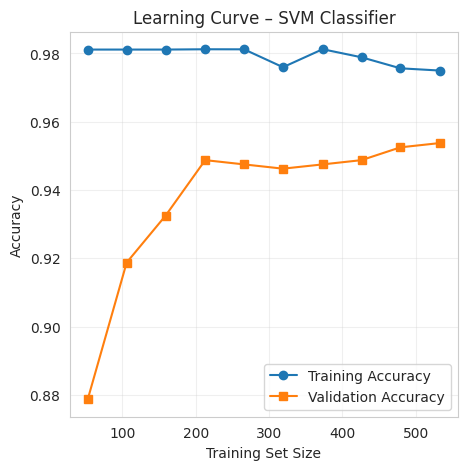

SVM Classifier:
Final Training Accuracy: 0.9750
Final Validation Accuracy: 0.9538
Gap: 0.0212


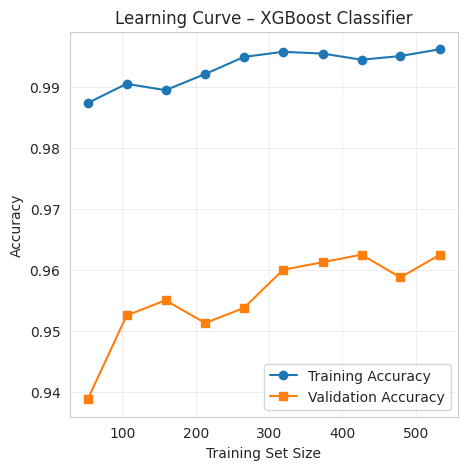

XGBoost Classifier:
Final Training Accuracy: 0.9962
Final Validation Accuracy: 0.9625
Gap: 0.0337


In [ ]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.1))
])

train_sizes, train_scores, test_scores = learning_curve(
    ridge_pipeline,
    X_train_reg,
    y_train_reg,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(5, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training R²')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R²')
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve – Ridge Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Ridge Regression:")
print(f"Final Training R²: {train_mean[-1]:.4f}")
print(f"Final Validation R²: {test_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - test_mean[-1]:.4f}")
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

train_sizes, train_scores, test_scores = learning_curve(
    xgb_reg,
    X_train_reg,
    y_train_reg,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(5, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training R²')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R²')
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve – XGBoost Regressor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("XGBoost Regressor:")
print(f"Final Training R²: {train_mean[-1]:.4f}")
print(f"Final Validation R²: {test_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - test_mean[-1]:.4f}")
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=3,
        gamma='scale',
        class_weight='balanced'
    ))
])

train_sizes, train_scores, test_scores = learning_curve(
    svm_pipeline,
    X_train_clf,
    y_train_clf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(5, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Accuracy')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – SVM Classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("SVM Classifier:")
print(f"Final Training Accuracy: {train_mean[-1]:.4f}")
print(f"Final Validation Accuracy: {test_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - test_mean[-1]:.4f}")
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.5,
    eval_metric='logloss',
    random_state=42
)

train_sizes, train_scores, test_scores = learning_curve(
    xgb_clf,
    X_train_clf,
    y_train_clf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(5, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Accuracy')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – XGBoost Classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("XGBoost Classifier:")
print(f"Final Training Accuracy: {train_mean[-1]:.4f}")
print(f"Final Validation Accuracy: {test_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - test_mean[-1]:.4f}")

##Validation Curve for the Models

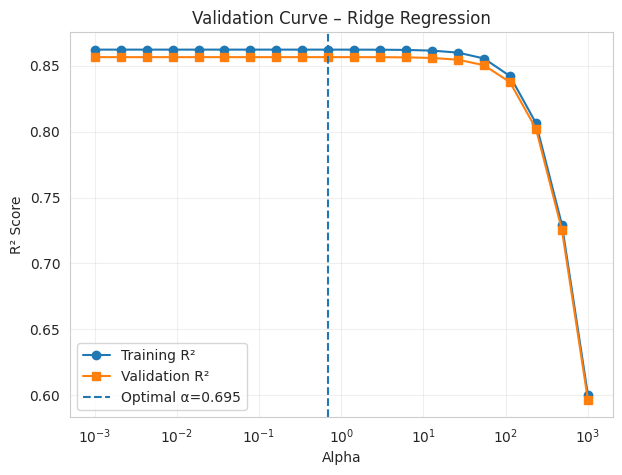

Optimal Alpha: 0.6952
Best CV R²: 0.8565


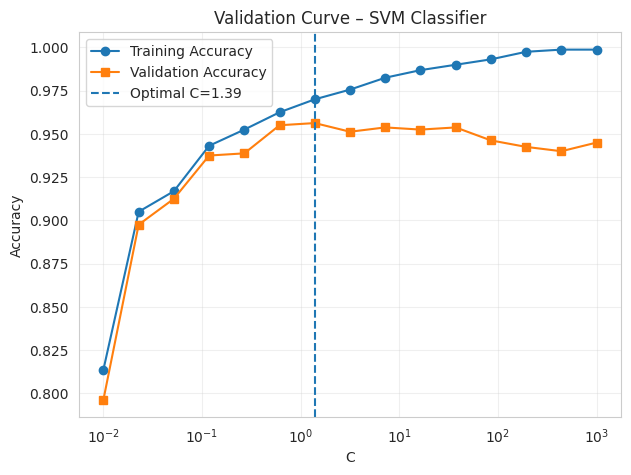

Optimal C: 1.3895
Best CV Accuracy: 0.9563


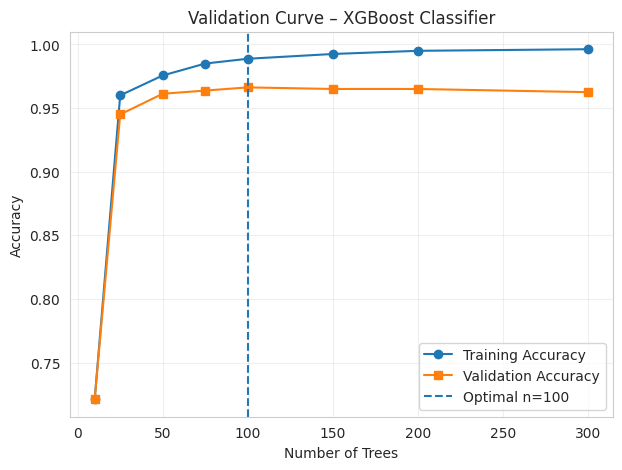

Optimal n_estimators: 100
Best CV Accuracy: 0.9663


In [ ]:
alpha_range = np.logspace(-3, 3, 20)

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

train_scores, test_scores = validation_curve(
    ridge_pipeline,
    X_train_reg,
    y_train_reg,
    param_name="ridge__alpha",
    param_range=alpha_range,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

optimal_alpha = alpha_range[np.argmax(test_mean)]

plt.figure(figsize=(7, 5))
plt.semilogx(alpha_range, train_mean, marker='o', label='Training R²')
plt.semilogx(alpha_range, test_mean, marker='s', label='Validation R²')
plt.axvline(optimal_alpha, linestyle='--', label=f'Optimal α={optimal_alpha:.3f}')
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Validation Curve – Ridge Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal Alpha: {optimal_alpha:.4f}")
print(f"Best CV R²: {test_mean.max():.4f}")
C_range = np.logspace(-2, 3, 15)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', gamma='scale', class_weight='balanced'))
])

train_scores, test_scores = validation_curve(
    svm_pipeline,
    X_train_clf,
    y_train_clf,
    param_name="svm__C",
    param_range=C_range,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

optimal_C = C_range[np.argmax(test_mean)]

plt.figure(figsize=(7, 5))
plt.semilogx(C_range, train_mean, marker='o', label='Training Accuracy')
plt.semilogx(C_range, test_mean, marker='s', label='Validation Accuracy')
plt.axvline(optimal_C, linestyle='--', label=f'Optimal C={optimal_C:.2f}')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Validation Curve – SVM Classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal C: {optimal_C:.4f}")
print(f"Best CV Accuracy: {test_mean.max():.4f}")
n_estimators_range = np.array([10, 25, 50, 75, 100, 150, 200, 300])

xgb_clf = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.5,
    eval_metric='logloss',
    random_state=42
)

train_scores, test_scores = validation_curve(
    xgb_clf,
    X_train_clf,
    y_train_clf,
    param_name="n_estimators",
    param_range=n_estimators_range,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

optimal_n = n_estimators_range[np.argmax(test_mean)]

plt.figure(figsize=(7, 5))
plt.plot(n_estimators_range, train_mean, marker='o', label='Training Accuracy')
plt.plot(n_estimators_range, test_mean, marker='s', label='Validation Accuracy')
plt.axvline(optimal_n, linestyle='--', label=f'Optimal n={optimal_n}')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Validation Curve – XGBoost Classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal n_estimators: {optimal_n}")
print(f"Best CV Accuracy: {test_mean.max():.4f}")

##Training Folds

In [ ]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.1))
])

kf = KFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_validate(
    ridge_pipe,
    X_train_reg,
    y_train_reg,
    cv=kf,
    scoring='r2',
    return_train_score=True
)


print("Ridge Regression (R²)")
for i in range(3):
    print(f"Fold {i+1} → Train: {scores['train_score'][i]:.4f}, "
          f"Val: {scores['test_score'][i]:.4f}")


print(f"Mean Train R²: {scores['train_score'].mean():.4f}")
print(f"Mean Val R²: {scores['test_score'].mean():.4f}")

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=3, kernel='rbf', gamma='scale', class_weight='balanced'))
])

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_validate(
    svm_pipe,
    X_train_clf,
    y_train_clf,
    cv=skf,
    scoring='accuracy',
    return_train_score=True
)

print("\nSVM Classifier (Accuracy)")
for i in range(3):
    print(f"Fold {i+1} → Train: {scores['train_score'][i]:.4f}, "
          f"Val: {scores['test_score'][i]:.4f}")

print(f"Mean Train Acc: {scores['train_score'].mean():.4f}")
print(f"Mean Val Acc: {scores['test_score'].mean():.4f}")

xgb_clf = XGBClassifier(
    n_estimators=optimal_n,   # from validation curve
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.5,
    eval_metric='logloss',
    random_state=42
)

scores = cross_validate(
    xgb_clf,
    X_train_clf,
    y_train_clf,
    cv=skf,
    scoring='accuracy',
    return_train_score=True
)

print("\nXGBoost Classifier (Accuracy)")
for i in range(3):
    print(f"Fold {i+1} → Train: {scores['train_score'][i]:.4f}, "
          f"Val: {scores['test_score'][i]:.4f}")

print(f"Mean Train Acc: {scores['train_score'].mean():.4f}")
print(f"Mean Val Acc: {scores['test_score'].mean():.4f}")

Ridge Regression (R²)
Fold 1 → Train: 0.8652, Val: 0.8530
Fold 2 → Train: 0.8663, Val: 0.8482
Fold 3 → Train: 0.8543, Val: 0.8711
Mean Train R²: 0.8619
Mean Val R²: 0.8575

SVM Classifier (Accuracy)
Fold 1 → Train: 0.9700, Val: 0.9588
Fold 2 → Train: 0.9775, Val: 0.9625
Fold 3 → Train: 0.9757, Val: 0.9511
Mean Train Acc: 0.9744
Mean Val Acc: 0.9575

XGBoost Classifier (Accuracy)
Fold 1 → Train: 0.9869, Val: 0.9738
Fold 2 → Train: 0.9906, Val: 0.9775
Fold 3 → Train: 0.9869, Val: 0.9474
Mean Train Acc: 0.9881
Mean Val Acc: 0.9662


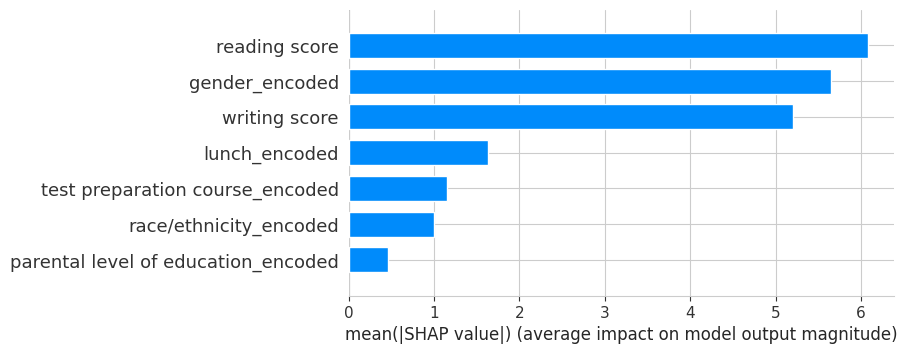

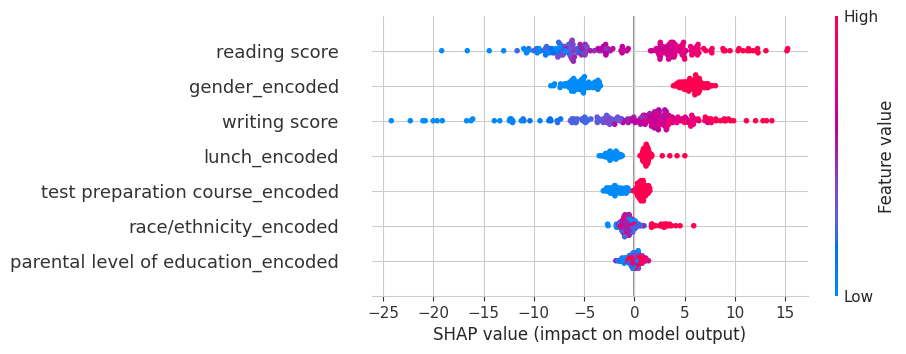

In [ ]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train_reg, y_train_reg)

explainer_reg = shap.TreeExplainer(xgb_reg)
shap_values_reg = explainer_reg.shap_values(X_test_reg)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_reg, X_test_reg, plot_type="bar", show=False)
plt.subplots_adjust(bottom=0.3, left=0.3)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=12)
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_reg, X_test_reg, show=False)
plt.subplots_adjust(bottom=0.3, left=0.3)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.show()

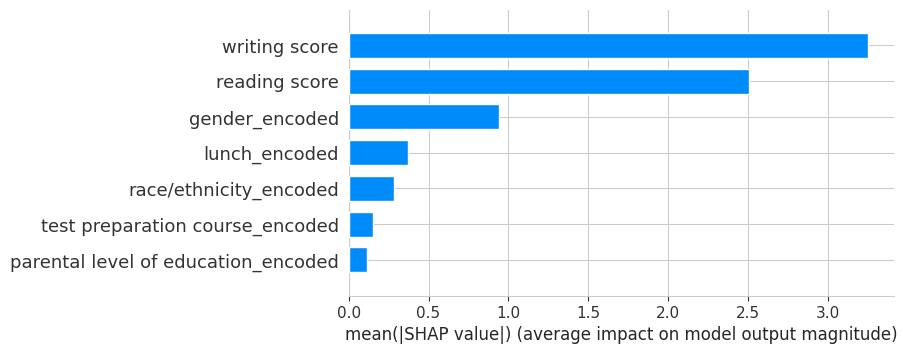

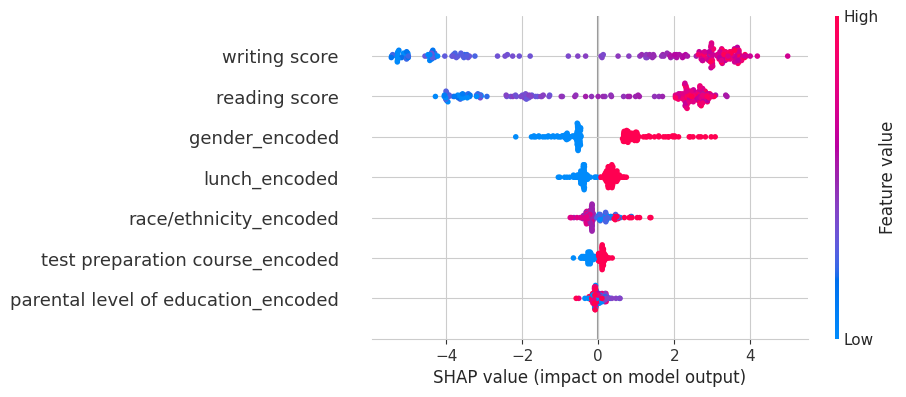

In [ ]:
from xgboost import XGBClassifier

# Train XGBoost Classifier
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=2.51,
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train_clf, y_train_clf)

explainer_clf = shap.TreeExplainer(xgb_clf)
shap_values_clf = explainer_clf.shap_values(X_test_clf)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_clf, X_test_clf, plot_type="bar", show=False)
plt.subplots_adjust(bottom=0.3, left=0.3)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=12)
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_clf, X_test_clf, show=False)
plt.subplots_adjust(bottom=0.2, left=0.3)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.show()


##Model Summary

In [ ]:
print("=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 80)

print("\nREGRESSION TASK (Predicting Math Score from Reading + Writing):")
print(f"  Ridge Regression       - R²: {ridge_r2:.4f}, MAE: {ridge_mae:.4f}")
print(f"  XGBoost Regressor      - R²: {xgb_r2:.4f}, MAE: {xgb_mae:.4f}")
print(f"  Winner: {'XGBoost Regressor' if xgb_r2 > ridge_r2 else 'Ridge Regression'}")

print("\nCLASSIFICATION TASK (Predicting Pass/Fail from Partial Scores):")
print(f"  Support Vector Machine - Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"  XGBoost Classifier     - Accuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print(f"  Winner: {'XGBoost Classifier' if xgb_accuracy > svm_accuracy else 'Support Vector Machine'}")

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

print("\n1. NO DATA LEAKAGE:")
print("   ✓ Classification uses ONLY demographics + reading/writing scores")
print("   ✓ Math score excluded to prevent data leakage")
print("   ✓ Realistic early-warning scenario")

print("\n2. CLASS IMBALANCE HANDLING:")
print("   ✓ SVM used class_weight='balanced'")
print("   ✓ XGBoost used scale_pos_weight=2.51")
print(f"   ✓ Fail class recall - SVM: {svm_metrics[1][0]:.2%}, XGBoost: {xgb_metrics[1][0]:.2%}")

print("\n3. REGRESSION - MOST IMPORTANT FEATURES:")
top_3_reg = importance_reg_df.head(3)
for idx, row in top_3_reg.iterrows():
    print(f"   • {row['Feature']}: {row['Importance']:.4f}")

print("\n4. CLASSIFICATION - MOST IMPORTANT FEATURES:")
top_3_clf = importance_clf_df.head(3)
for idx, row in top_3_clf.iterrows():
    print(f"   • {row['Feature']}: {row['Importance']:.4f}")

print("\n5. MODEL RECOMMENDATIONS:")
if xgb_r2 > ridge_r2:
    print(f"   ✓ Regression: XGBoost Regressor (R²={xgb_r2:.4f})")
else:
    print(f"   ✓ Regression: Ridge Regression (R²={ridge_r2:.4f})")

if xgb_accuracy > svm_accuracy:
    print(f"   ✓ Classification: XGBoost Classifier (Acc={xgb_accuracy*100:.2f}%)")
else:
    print(f"   ✓ Classification: Support Vector Machine (Acc={svm_accuracy*100:.2f}%)")

print("\n6. PRACTICAL APPLICATIONS:")
print("   • Early identification of at-risk students (after 2 of 3 tests)")
print("   • Predict missing test scores from available results")
print("   • Data-driven intervention targeting")
print("   • Resource allocation optimization")

print("\n7. ADVANCED TECHNIQUES USED:")
print("   • Ridge Regression: L2 regularization for multicollinearity")
print("   • Support Vector Machine: RBF kernel for non-linear boundaries")
print("   • XGBoost: Gradient boosting with sequential error correction")
print("   • Feature scaling: StandardScaler for SVM optimization")
print("   • Class balancing: Weighted loss functions for imbalanced data")

print("\n" + "=" * 80)
print(" ANALYSIS COMPLETE - ADVANCED ML MODELS IMPLEMENTED!")
print("=" * 80)

FINAL MODEL PERFORMANCE SUMMARY

REGRESSION TASK (Predicting Math Score from Reading + Writing):
  Ridge Regression       - R²: 0.8838, MAE: 4.1302
  XGBoost Regressor      - R²: 0.8540, MAE: 4.6598
  Winner: Ridge Regression

CLASSIFICATION TASK (Predicting Pass/Fail from Partial Scores):
  Support Vector Machine - Accuracy: 0.9350 (93.50%)
  XGBoost Classifier     - Accuracy: 0.9650 (96.50%)
  Winner: XGBoost Classifier

KEY FINDINGS

1. NO DATA LEAKAGE:
   ✓ Classification uses ONLY demographics + reading/writing scores
   ✓ Math score excluded to prevent data leakage
   ✓ Realistic early-warning scenario

2. CLASS IMBALANCE HANDLING:
   ✓ SVM used class_weight='balanced'
   ✓ XGBoost used scale_pos_weight=2.51
   ✓ Fail class recall - SVM: 95.16%, XGBoost: 91.94%

3. REGRESSION - MOST IMPORTANT FEATURES:
   • Reading Score: 0.3521
   • Gender: 0.3398
   • Writing Score: 0.1785

4. CLASSIFICATION - MOST IMPORTANT FEATURES:
   • Writing Score: 0.4262
   • Reading Score: 0.3128
   • G

#Testing

In [ ]:
print("STUDENT PERFORMANCE PREDICTION SYSTEM\n")
print("\n Please enter student information:\n")

def get_int_input(prompt, valid_values):
    while True:
        try:
            value = int(input(prompt))
            if value in valid_values:
                return value
            else:
                print(f" Invalid input. Allowed values: {valid_values}")
        except ValueError:
            print(" Please enter a valid integer.")


def get_score(prompt):
    while True:
        try:
            score = float(input(prompt))
            if 0 <= score <= 100:
                return score
            else:
                print(" Score must be between 0 and 100.")
        except ValueError:
            print(" Please enter a valid number.")

print("DEMOGRAPHIC INFORMATION:")
print("-" * 40)

print("\nGender:")
print("  0 = Female")
print("  1 = Male")
gender = get_int_input("Enter gender (0 or 1): ", [0, 1])

print("\nRace/Ethnicity:")
print("  0 = Group A")
print("  1 = Group B")
print("  2 = Group C")
print("  3 = Group D")
print("  4 = Group E")
race = get_int_input("Enter race/ethnicity (0-4): ", [0, 1, 2, 3, 4])

print("\nParental Level of Education:")
print("  0 = Some high school")
print("  1 = High school")
print("  2 = Some college")
print("  3 = Associate's degree")
print("  4 = Bachelor's degree")
print("  5 = Master's degree")
parent_edu = get_int_input("Enter parental education (0-5): ", [0, 1, 2, 3, 4, 5])

print("\nLunch Type:")
print("  0 = Free/Reduced")
print("  1 = Standard")
lunch = get_int_input("Enter lunch type (0 or 1): ", [0, 1])

print("\nTest Preparation Course:")
print("  0 = None")
print("  1 = Completed")
test_prep = get_int_input("Enter test prep status (0 or 1): ", [0, 1])

print("\n" + "-" * 40)
print("ACADEMIC SCORES:")
print("-" * 40)

reading_score = get_score("Enter Reading Score (0-100): ")
writing_score = get_score("Enter Writing Score (0-100): ")

input_data = np.array([[
    gender,
    race,
    parent_edu,
    lunch,
    test_prep,
    reading_score,
    writing_score
]])

input_data_scaled_reg = scaler_reg.transform(input_data)  # Ridge
input_data_scaled_clf = scaler_clf.transform(input_data)  # SVM

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train_reg, y_train_reg)

xgb_clf = XGBClassifier(
    n_estimators=optimal_n,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=2.51,
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train_clf, y_train_clf)

def categorize_grade(score):
    if score >= 80:
        return 'Excellent'
    elif score >= 70:
        return 'Good'
    elif score >= 60:
        return 'Average'
    else:
        return 'Below Average'

print("\n" + "=" * 80)
print("PREDICTION RESULTS")
print("=" * 80)

ridge_pred_math = ridge_model.predict(input_data_scaled_reg)[0]
xgb_pred_math = xgb_reg.predict(input_data)[0]
avg_pred_math = (ridge_pred_math + xgb_pred_math) / 2

print("\n GRADE ESTIMATION (Math Score Prediction):")
print("-" * 60)

print(f"\n  Ridge Regression predicts: {ridge_pred_math:.2f} ({categorize_grade(ridge_pred_math)})")
print(f"  XGBoost Regressor predicts: {xgb_pred_math:.2f} ({categorize_grade(xgb_pred_math)})")
print(f"  Average Prediction: {avg_pred_math:.2f} ({categorize_grade(avg_pred_math)})")

print("\n" + "-" * 60)
print(" PASS / FAIL PREDICTION")
print("-" * 60)

svm_pred = svm_clf.predict(input_data_scaled_clf)[0]
svm_proba = svm_clf.predict_proba(input_data_scaled_clf)[0]

xgb_pred = xgb_clf.predict(input_data)[0]
xgb_proba = xgb_clf.predict_proba(input_data)[0]

print(f"\n  SVM Prediction: {'PASS' if svm_pred else 'FAIL'}")
print(f"    Confidence → Pass: {svm_proba[1]*100:.1f}% | Fail: {svm_proba[0]*100:.1f}%")

print(f"\n  XGBoost Prediction: {'PASS' if xgb_pred else 'FAIL'}")
print(f"    Confidence → Pass: {xgb_proba[1]*100:.1f}% | Fail: {xgb_proba[0]*100:.1f}%")

estimated_avg = (avg_pred_math + reading_score + writing_score) / 3
overall_category = categorize_grade(estimated_avg)

print("\n" + "-" * 60)
print(" FINAL PERFORMANCE SUMMARY")
print("-" * 60)

print(f"\n Reading Score:  {reading_score:.1f}")
print(f" Writing Score:  {writing_score:.1f}")
print(f" Math (Pred.):   {avg_pred_math:.2f}")

print(f"\n Estimated Overall Average: {estimated_avg:.2f}")
print(f" Overall Category: {overall_category}")

print(f"\n FINAL DECISION: {'STUDENT WILL PASS' if estimated_avg >= 60 else 'STUDENT AT RISK OF FAILING'}")


STUDENT PERFORMANCE PREDICTION SYSTEM


 Please enter student information:

DEMOGRAPHIC INFORMATION:
----------------------------------------

Gender:
  0 = Female
  1 = Male


KeyboardInterrupt: Interrupted by user